## Table of Contents

- [1.0 Graph Autoencoders](#10-graph-autoencoders)
- [2.0 Graph Autoencoder Pipeline](#20-graph-autoencoder-pipeline)
- [3.0 Implementing a GAE for the Pinwheel Network using Pytorch GeometricNetwork](#30-implementing-a-gae-for-the-pinwheel-network-using-pytorch-geometricnetwork)
- [4.0 GAE Decoder and Loss Function](#40-gae-decoder-and-loss-function)
- [5.0 Manual Training for a Learning GAE](#50-manual-training-for-a-learning-gae)
- [6.0 Experiments With Different GAE Architectures](#60-experiments-with-different-gae-architectures)
  - [6.1 Wrap Training and Negative Sampling in a Helper Class](#61-wrap-training-and-negative-sampling-in-a-helper-class)
  - [6.2 Output Layer Only](#62-output-layer-only)
  - [6.3 One Hidden Layer Plus an Output Layer](#63-one-hidden-layer-plus-an-output-layer)
  - [6.4 Change the Embedding Width](#64-change-the-embedding-width)
  - [6.5 What if the embedding has three dimensions instead of two?](#65-what-if-the-embedding-has-three-dimensions-instead-of-two)
  - [6.6 Three Hidden Layers and One Output Layer](#66-three-hidden-layers-and-one-output-layer)
- [7.0 Repeat the Workflow with Simulated Features](#70-repeat-the-workflow-with-simulated-features)
- [8.0 Graph Autoencoder for the Karate Graph](#80-graph-autoencoder-for-the-karate-graph)

### 1.0 Graph Autoencoders

An autoencoder uses a neural network to transform an input into a low-dimensional representation of the input, just like we've been doing with node embedding. The purpose of this tutorial is to teach how to implement an autoencoder for graphs using by demonstrating a couple of implementations using `pytorch geometric`.


#### 1.1 Graph Autoencoders and GCNs
A _graph autoencoder_ (GAE) uses the graph convolutional neural networks discussed in the last tutorial and specifies an error function to be used to update the hidden layer weights.

The forward pass of a GCN _encodes_ data and forms a node embedding. What is done with the embedding is called _decoding_, and the form of decoding is determined by what goal you are trying to accomplish with the graph neural network (GNN). 


#### 1.2 GAE Encoding and Decoding

A graph autoencoder (GAE) uses convolution to encode an input in a useful embedding. In a GAE, the decoder tries to reconstruct the input. I was trained as an engineer so I think of encoding as data compression. A good compression algorithm does two things:
 - it represents the original object using fewer "bits" than in the original object
 - it can be used to reconstruct the original object, hopefully with little loss of accuracy 
 
 The encoder compresses the object, and the decoder decompresses itFormally speaking, the process of turning the original object into the compressed representation is called __encoding__, and the process of turning the compressed representation into an approximation of the original object is called __decoding__.  The key insight is that the network tries to reconstruct its input from the low-dimensional embedding, as illustrated in the following figure.

<img src="figures/autoencoder.png" alt="eneral autoencoder architecture" width = "600">

The compressed representation is often called a _latent representation_. One meaning of the word "latent" is "hidden or dormant". The idea is that the compressed representation captures the fundamental structures hidden in the original object while getting rid of the parts of the original object that aren't necessary. It's like saying we've found the small representation hidden by the large representation of the original object. In the graph machine learning context, the output of a graph autoencoder is called a _node embedding_ instead of the _latent representation_. I hope that the reason is fairly obvious: we are using the GCN to find a low-dimensional embedding of the original network structure. 

The difference between the decoded output and input gives us an error signal that can be used to update the weights used in the GCN. More generally, the error is a measure the difference between and output and the desired output, and this error is _back propagated_ through the network updating the weights in the hidden layers.

---


### 2.0 Graph Autoencoder Pipeline

We'll now discuss the data processing pipeline for a GAE. The goal will be to review the pytorch.geometric tools used to implement a GAE at the same time that we mathematically define the error function.
This part of the tutorial relies heavily on the [presentation from Antonio Longa](https://antoniolonga.github.io/Pytorch_geometric_tutorials/posts/post6.html), and the [Jupyter notebook used in the presentation](https://github.com/AntonioLonga/PytorchGeometricTutorial/blob/main/Tutorial6/Tutorial6.ipynb). 


#### 2.1 Put the graph into the pytorch data structure

These examples will implement the GCN using pytorch. 
We'll demonstrate the steps using the pinwheel graph, first without features and then with features.

We'll be using a graph convolutional neural network to construct our graph autoencoder. GCNs include self-loops so that messages passed from neighbors to a node are aggregated with the node's current signal (e.g., feature vector). The GCN class in `pytorch-geometric` automatically includes self-loops, so we don't need to worry about adding them.

#### 2.1.1 Pinwheel Graph Example

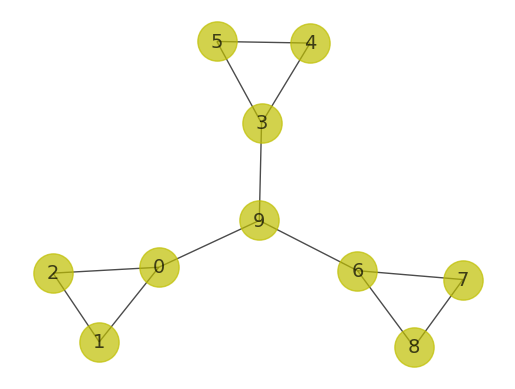

In [320]:
#############
## CELL 1  ##
#############

import networkx as nx
import matplotlib.pyplot as plt

pinwheel_graph = nx.Graph()
pinwheel_graph.add_nodes_from([0,1,2,3,4,5,6,7,8,9])
pinwheel_graph.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(4,5),(6,7),(6,8),(7,8),(0,9),(3,9),(6,9)])
plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color='y',
                 node_size=800,
                 font_size=14,
                 alpha = 0.7)
_ = plt.axis('off')

#### 2.1.2 Convert Networkx Graph to Pytorch `Data` Type
Call the pytorch geometric utility `from_networkx` to convert the networkx graph into the pytorch `Data` type.

In [321]:
#############
## CELL 2  ##
#############
import numpy as np
from torch_geometric.utils import from_networkx
from torch import Tensor
from torch_geometric.data import Data as PyGData
data: PyGData = from_networkx(pinwheel_graph)      # convert to pytorch data structure
print(f"Pinwheel graph as pytorch data structure is\n\t {data}")

Pinwheel graph as pytorch data structure is
	 Data(edge_index=[2, 24], num_nodes=10)


#### 2.1.3 Review Parts of Pytorch Geometric `Data` Object

Recall that the `data` class member `data.edge_index` represents the edge set of the graph as a tensor. For the purposes of CS 575, we can think of tensors as a data type that can include both vectors and matrices. The first index of `edge_index` contains the ordered edge pair. The second index is the number of edges. Each edge is directed, which means that an undirected graph with an edge $\{u,v\}$ appears wtice in the edge_index: once as $(u,v)$ and again as $(v,u)$.

Confirm the contents of `edge_index` by printing out relevant information.


In [322]:
#############
## CELL 3  ##
#############
for i in {0,1,2,3}:
    print(f"edge {i} is {data.edge_index[:,i]}")

edge 0 is tensor([0, 1])
edge 1 is tensor([0, 2])
edge 2 is tensor([0, 9])
edge 3 is tensor([1, 0])


#### 2.1.4 Represent Node Features in `Data` Object Using One-hot Encoding

When a graph is imported that does not specify node features, the `from_networkx` utility Leaves the `data.x` class member empty. We'll therefore make up node features using _one-hot encoding_. Assign and inspect the `data.x` class member to use one-hot encoding.

In [323]:
#############
## CELL 4  ##
#############
data.x = Tensor(np.eye(len(pinwheel_graph)))  # labels features using one-hop encoding
for node in [0,1,2,3,9]:
    print(f'x values node {node}: \n\t{data.x[node]}')
data.num_node_features = len(data.x)

x values node 0: 
	tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
x values node 1: 
	tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
x values node 2: 
	tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
x values node 3: 
	tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])
x values node 9: 
	tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


The size of the vector used to encode node features is given by the class member `data.num_node_features`.

In [324]:
print(data.num_node_features)

10


#### 2.2 Review of Graph Autoencoder Computation Math

The graph autoencoder that we'll implement is based on equations (3) and (4) from

```
    Pan, S., Hu, R., Long, G., Jiang, J., Yao, L., & Zhang, C. (2018). Adversarially regularized graph autoencoder for graph embedding. arXiv preprint arXiv:1802.04407.
```

The encoder consists of two GCN layers and one decoder layer. 

<img src="figures/graph_autoencoder.png" alt="Graph autoencoder example" width = "500">



#### 2.2.1 First and Second Hidden Layers

The encoder has two hidden layers. For the first layer, $h1$ is computed using the matrix multiplications defined above 

$$ \hat{H} ^{(1)} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} X W^{(1)}$$

and then passing through a rectified linear unit

$$ {H} ^{(1)} = f_{\rm ReLu}\left(\hat{H} ^{(1)}\right) $$

The rectified linear unit sets everything less than zero to zero and anything else to its original value,

$$ f_{\rm ReLu}(x) = \left\{ \begin{array}{rl} 0 & {\rm if\ } x < 0 \\ x & {\rm otherwise}\end{array}\right. $$

The **second hidden layer** repeats the computation of the first hidden layer.

$$ \hat{H}^{(2)} = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(1)} W^{(2)}$$

and then passing through a rectified linear unit

$$ {H} ^{(2)} = f_{\rm ReLu}\left(\hat{H} ^{(2)}\right)  $$


#### 2.2.2 Output Layer
The output layer computes the embedding. Recall that a node embedding was a mapping from the set of graph nodes to a $d$-dimensional real-valued vector $ f: V\rightarrow {\mathbf R}^d $. 

Let ${\mathbf z}_i = f({\mathbf x}_i)$, where ${\mathbf x}_i$ is the one-hot encoding for node $i$. The vector $Z$ for all nodes embedings ${\mathbf z}_i$ is computed using

$$ Z = \tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(2)} W^{(3)}$$

We won't pass $Z$ through an activation fuction because we want the vector output to have a full range of positive and negative real values.

---


### 3.0 Implementing a GAE for the Pinwheel Network using Pytorch GeometricNetwork

Let's now implement the GAE for the equations above with two hidden layers and one output layer. Each layer will use a graph convolutional neural network. This section will first show what happens if we don't do any learning, and then introduce the additional elements in the GAE implementation that allow learning.



#### 3.1 GAE Implementation
As with the GCN tutorial, we'll focus on specifying the architecture elements in the `__init__` function and specify the series of computations in the `forward` function.

In [325]:
#############
## CELL 5  ##
#############
from torch_geometric.nn import GAE
import torch
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

class Encoder_With_Three_Layers(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder_With_Three_Layers, self).__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 8 * out_channels)
        self.hidden_layer_2 = GCNConv(8 * out_channels, 2 * out_channels)
        self.output_layer = GCNConv(2 * out_channels, out_channels)
        
    def forward(self, data: PyGData): 
        x, edge_index = data.x, data.edge_index
        h1 = self.hidden_layer_1(x, edge_index)
        squashed_h1 = F.relu(h1)    
        h2 = self.hidden_layer_2(squashed_h1, edge_index)
        squashed_h2 = F.relu(h2)    
        z = self.output_layer(squashed_h2, edge_index)
        return z

#### 3.1.1 Side-by-Side: GAE Encoder vs GCN Model

The implementation of the GAE should look familiar to you. Indeed, it is almost identical to what we did in the GCN tutorial. Here's the code of the GCN we implemented for the pinwheel graph.

```python
class ThreeLayerGCN(nn.Module):
    def __init__(self, in_channels: int, hidden_channels_1: int, hidden_channels_2: int, out_channels: int):
        super().__init__()
        self.hidden1 = GCNConv(in_channels, hidden_channels_1)
        self.hidden2 = GCNConv(hidden_channels_1, hidden_channels_2)
        self.output = GCNConv(hidden_channels_2, out_channels)

    def forward(self, data: PygData) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        h1 = self.hidden1(x, edge_index)  # shape: [N, hidden_channels_1]
        h1 = F.relu(h1)
        h2 = self.hidden2(h1, edge_index)  # shape: [N, hidden_channels_2]
        h2 = F.relu(h2)
        out = self.output(h2, edge_index)  # shape: [N, out_channels]
        return out
```


Let's compare each element of the GAE implementation to the corresdponding element of the GCN. We'll begin with the initalizer.

**Initializer Comparison (__init__)**

| Aspect | GAE Encoder: Encoder_With_Three_Layers | GCN Model: ThreeLayerGCN |
|---|---|---|
| Signature | __init__(in_channels, out_channels) | __init__(in_channels, hidden_channels_1, hidden_channels_2, out_channels) |
| Width control | Hidden widths are fixed as multiples of out_channels | Hidden widths are explicitly passed in |
| Layer definitions | hidden_layer_1: in -> 8*out, hidden_layer_2: 8*out -> 2*out, output_layer: 2*out -> out | hidden1: in -> h1, hidden2: h1 -> h2, output: h2 -> out |

The only difference is that the GAE specifies only the sizes of the input and output layer. This is **not a GAE feature**; rather, it is just a choice we made and we could have designed the GCN the same way. We'll see that more clearly when we look at the implementation for `forward`.



**Forward Comparison (forward)**

| Aspect | GAE Encoder forward | GCN Model forward |
|---|---|---|
| Signature | forward(data) | forward(data) -> torch.Tensor |
| Input unpacking | x, edge_index = data.x, data.edge_index | x, edge_index = data.x, data.edge_index |
| Computation flow | GCN -> ReLU -> GCN -> ReLU -> GCN | GCN -> ReLU -> GCN -> ReLU -> GCN |
| Returned tensor | z (latent embedding) | out (task output embedding/logits depending on usage) |

The implementations are, again, identical except for how we specified the sizes of the hidden layers. 

So, what is different between the GCN and the GAE? 

#### 3.1.2 What About Learning

The implementation for the GCN didn't include the elements of the neural network class that enable learning. Specifically, we didn't implement

 - _loss_: Compute an error, which is some form of difference between what the network generated and what we wanted to compute. 
 - _backward_: Propagate the loss back through the network to update the weights.
 - _optimize_: Let whatever (stochastic gradient descent) optimizer being used know to take a step in the direction of the gradient

Let's look at how the GAE implements these, even though they aren't specified in the GAE class above.




#### 3.1.3 Differences between GCN and GAE

Let's do a comparison of how we instantiate the GAE and GCN, respectively.


**GAE Instantiation**

```python
# Instantiate GAE
out_channels = 4
num_features = data.num_features
gae = GAE(Encoder_With_Three_Layers(num_features, out_channels))
gae.eval()   # Set the model to evaluation mode
# Forward pass
with torch.no_grad():               # Disable gradient tracking for inference
    node_embeddings = gae(data)  # Shape: [10, 4]
```

**GCN Instantiation**

```python
in_dim       = data.x.shape[1]  # size of feature vector
hidden_dim_1 = 128              # first compression:  384 → 128
hidden_dim_2 = 64               # second compression: 128 → 64
out_dim      = 32               # final embedding:     64 → 32

# Instantiate
gcn = ThreeLayerGCN(in_dim, hidden_dim_1, hidden_dim_2, out_dim)
gcn.eval()  # Set the model to evaluation mode
# Forward pass
print("\nStep 3: Run the untrained forward pass.")
with torch.no_grad():
    node_embeddings = gcn(data)  # shape: [N, out_dim]
```

**Key Implementation Difference between GAE and GCN**

Other than the differences in how hidden layer dimensions are specified,  the key structural difference is that the GAE model wraps an encoder inside the GAE class (which provides decoding and reconstruction-loss machinery), while the GCN model is instantiated directly as a standalone network without autoencoder-specific components. In code, the gae model is wrapped inside an existing `pytorch-geometric` class called GAE. 
```python
   gae = GAE(Encoder_With_Three_Layers(num_features, out_channels))
```
in contrast to the gcn which is a standalone network
```python
   gcn = ThreeLayerGCN(in_dim, hidden_dim_1, hidden_dim_2, out_dim)
```
No wrapper is added. It is just a model that maps node features to outputs through forward. 

In [326]:
#############
## CELL 6  ##
#############

# parameters
# out_channels is the number of output channels for the final layer
# in_channels is the number of input channels for the first layer
# num_features is the number of features for each node
# in_channels = data.num_node_features
out_channels = 4
num_features = data.num_features

# Instantiate the model
# The model is a GAE (Graph Autoencoder) with three layers
# The Encoder_With_Three_Layers class is used to define the encoder part of the GAE
gae = GAE(Encoder_With_Three_Layers(num_features, out_channels))
gae.eval()  # Set the model to evaluation mode

# Forward pass
with torch.no_grad():               # Disable gradient tracking for inference
    # Get node embeddings from the model
    # Note: data is a PyG Data object with attributes x (node features) and edge_index (graph connectivity)
    # The model returns a tensor of shape (num_nodes, out_dim)
     # where num_nodes is the number of nodes in the graph and out_dim is the final embedding size
    node_embeddings = gae(data)  # Shape: [10, 4]

print(f"The node embeddings has {len(pinwheel_graph)} rows, one for each node in the graph")
print(f"and {out_channels} columns, one for each output channel")
print(f"The node embeddings are:\n{node_embeddings}")
print(f"The node embeddings are of shape {node_embeddings.shape}")

The node embeddings has 10 rows, one for each node in the graph
and 4 columns, one for each output channel
The node embeddings are:
tensor([[ 0.0489,  0.1674,  0.1635,  0.1852],
        [ 0.0346,  0.1553,  0.1369,  0.1805],
        [ 0.0346,  0.1553,  0.1369,  0.1805],
        [ 0.0162,  0.1348,  0.1038,  0.0930],
        [-0.0031,  0.1177,  0.0681,  0.0740],
        [-0.0031,  0.1177,  0.0681,  0.0740],
        [ 0.1070,  0.1417,  0.2309,  0.1032],
        [ 0.1016,  0.1256,  0.2148,  0.0858],
        [ 0.1016,  0.1256,  0.2148,  0.0858],
        [ 0.0613,  0.1442,  0.1693,  0.1244]])
The node embeddings are of shape torch.Size([10, 4])


#### 3.1.4 Why the GAE Wrapper?
The generic graph neural network specified in the class
```python 
Encoder_With_Three_Layers
```
acts as an `encoder`. The forward pass transforms the graph and its features into an embedding. Putting this encoder inside the `GAE` class wrapper
```python
GAE(Encoder_With_Three_Layers(num_features, out_channels))
```
adds autoencoder behavior on top of the encoder.  Specifically, we get three things "for free":

- a decoder (default inner-product decoder)
- reconstruction-loss utilities (for example recon_loss)
- helper methods like encode and decode

The next section talks about the decoder.


### 4.0 GAE Decoder and Loss Function 

Recall that the goal is to take node $i$, call it $u_i$, and compute a real-valued vector representation of the node, call it ${\mathbf z}_i$. We want the embedding to satisfy the property that two similar nodes end up close to each other in the embedding space. Each ${\mathbf z}_i$ is stored as a row in the `node_embeddings` object, which means that ${\mathbf z}_i\in \mathbb{R}^d$ for the embedding dimension $d=4$. Thus, the embedding of node $0$ is the first row of node_embeddings

In [327]:
#############
## CELL 7  ##
#############

print(f"Node {0}'s embedding is {node_embeddings[0]}")
print(f"Node {1}'s embedding is {node_embeddings[1]}")
print(f"Node {2}'s embedding is {node_embeddings[2]}")

Node 0's embedding is tensor([0.0489, 0.1674, 0.1635, 0.1852])
Node 1's embedding is tensor([0.0346, 0.1553, 0.1369, 0.1805])
Node 2's embedding is tensor([0.0346, 0.1553, 0.1369, 0.1805])


Recall further that the process of creating node embeddings is to find a function $f:V\mapsto\mathbb{R}^d$ such that if two vertices are similar than the distance between their embeddings is small. 

- if ${\rm sim}(u_i, u_j)$ is high then we want ${\mathbf z}_i$ to be near ${\mathbf z}_j$.

For a graph convolutional autoencoder, we need to define what we mean both by _similar_ and by _near_. 

- We'll use adjacency to define _similar_, so two nodes are similar if $A_{ij}=1$.
- We'll use cosine similarity as the metric for _near_, so we want ${\mathbf z}_i{\mathbf z}j^T$ to be high.


#### 4.1 Decoder

Constructing the decoder has two parts: computing the inner product, and using the sigmoid function.

#### 4.1.1 Inner Product

The inner product ${\mathbf z}_i{\mathbf z}j^T$ **is the decoder** specified by default in the GAE class. Note that the embeddings are row vectros, so the inner product formulation puts the transpose on the second vector.

Let's inspect the inner product for nodes 1 and 2, which are right next to each other in the pinwheel graph.


In [328]:
#############
## CELL 8  ##
#############

print(f"The inner product for nodes 1 and 2 is {torch.dot(node_embeddings[1], node_embeddings[2])}")

The inner product for nodes 1 and 2 is 0.07664813101291656


By contrast, let's inspect the inner product for the embeddings of vertex 1 and 4, which are not close to each other in the pinwheel graph.

In [329]:
#############
## CELL 9  ##
#############
 
print(f"The inner product for nodes 1 and 4 is {torch.dot(node_embeddings[1], node_embeddings[4])}")

The inner product for nodes 1 and 4 is 0.04085350036621094


Before training, the inner-product values are likely similar because the GCN weights are still random. To make the objective explicit, we want connected nodes (for example, nodes 1 and 2) to have a high similarity score, and unconnected nodes (for example, nodes 1 and 4) to have a low score, possibly near 0. Rather than hand-specifying target inner products for every node pair, we use the graph itself as supervision. In practice, we map inner products through a sigmoid and train so those values align with the entries of the graph’s adjacency matrix.


Let's inspect what happens if we try to estimate the adjacency matrix using the raw embeddings. Here's part of the actual adjacency matrix:


In [330]:
#############
## Cell 10 ##
#############

from scipy.sparse import csr_matrix
A_sparse: csr_matrix = nx.adjacency_matrix(pinwheel_graph)
A: np.ndarray = A_sparse.todense()  # convert sparse matrix to dense

print(f"A = \n{A}")
print(f"Upper left corner of A = \n{A[0:3,0:3]}")  # print first three rows and columns

A = 
[[0 1 1 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0 1]
 [0 0 0 1 0 1 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 1 1 0 0]
 [1 0 0 1 0 0 1 0 0 0]]
Upper left corner of A = 
[[0 1 1]
 [1 0 1]
 [1 1 0]]


Here's the estimate when we take the inner produce of all node embeddings.

In [331]:
#############
## Cell 11 ##
#############

# Compute and inspect product of node embeddings
zzT = node_embeddings@node_embeddings.T
print(f"ZZ^T = has {zzT.shape[0]} rows and {zzT.shape[1]} columns")
print(f"ZZ^T = \n{zzT}")
print(f"Upper left corner of ZZ^T = \n{zzT[0:3,0:3]}")  # print first three rows and columns

ZZ^T = has 10 rows and 10 columns
ZZ^T = 
tensor([[0.0914, 0.0835, 0.0835, 0.0576, 0.0444, 0.0444, 0.0858, 0.0770, 0.0770,
         0.0779],
        [0.0835, 0.0766, 0.0766, 0.0525, 0.0409, 0.0409, 0.0760, 0.0679, 0.0679,
         0.0702],
        [0.0835, 0.0766, 0.0766, 0.0525, 0.0409, 0.0409, 0.0760, 0.0679, 0.0679,
         0.0702],
        [0.0576, 0.0525, 0.0525, 0.0379, 0.0298, 0.0298, 0.0544, 0.0489, 0.0489,
         0.0496],
        [0.0444, 0.0409, 0.0409, 0.0298, 0.0240, 0.0240, 0.0397, 0.0354, 0.0354,
         0.0375],
        [0.0444, 0.0409, 0.0409, 0.0298, 0.0240, 0.0240, 0.0397, 0.0354, 0.0354,
         0.0375],
        [0.0858, 0.0760, 0.0760, 0.0544, 0.0397, 0.0397, 0.0955, 0.0871, 0.0871,
         0.0789],
        [0.0770, 0.0679, 0.0679, 0.0489, 0.0354, 0.0354, 0.0871, 0.0796, 0.0796,
         0.0714],
        [0.0770, 0.0679, 0.0679, 0.0489, 0.0354, 0.0354, 0.0871, 0.0796, 0.0796,
         0.0714],
        [0.0779, 0.0702, 0.0702, 0.0496, 0.0375, 0.0375, 0.0789, 0.

#### 4.1.2 Using Sigmoid to Estimate Adjacency Entries

The decoder first computes a raw similarity score for each pair of nodes using an inner product: ${\mathbf z}_i{\mathbf z}_j^T$.
These scores can be any real number, so they are not directly usable as adjacency estimates.

To turn these raw scores into values we can compare to adjacency entries, we pass them through the sigmoid function:

$$ \sigma({\mathbf z}_i{\mathbf z}_j^T) = \frac{1}{1+e^{-{\mathbf z}_i{\mathbf z}_j^T}} $$

This maps every score into the interval $(0,1)$, so each output can be interpreted as an estimated probability that an edge exists between nodes $i$ and $j$.
In other words, the model uses

$$ \hat{A}_{ij} = \sigma({\mathbf z}_i{\mathbf z}_j^T) $$

as its estimate of the adjacency-matrix entry $A_{ij}$.
At the matrix level, this is

$$ \hat{A} = \sigma(ZZ^T) $$

where sigmoid is applied elementwise. The decoder performs this conversion from embedding similarities to adjacency estimates for us.

Let's inspect how well this estimate of the adjacency matrix matches the correct adjacency matrix before training.


In [333]:
#############
## Cell 12 ##
#############

import torch

# Pass through sigmoid and inspect
A_pred = torch.sigmoid(zzT)

print(f"A_pred = \n{A_pred}")
print(f"Upper left corner of sigma(zzT) = \n{A_pred[0:3,0:3].detach().numpy()}")  # print first three rows and columns

A_pred = 
tensor([[0.5228, 0.5209, 0.5209, 0.5144, 0.5111, 0.5111, 0.5214, 0.5192, 0.5192,
         0.5195],
        [0.5209, 0.5192, 0.5192, 0.5131, 0.5102, 0.5102, 0.5190, 0.5170, 0.5170,
         0.5175],
        [0.5209, 0.5192, 0.5192, 0.5131, 0.5102, 0.5102, 0.5190, 0.5170, 0.5170,
         0.5175],
        [0.5144, 0.5131, 0.5131, 0.5095, 0.5074, 0.5074, 0.5136, 0.5122, 0.5122,
         0.5124],
        [0.5111, 0.5102, 0.5102, 0.5074, 0.5060, 0.5060, 0.5099, 0.5089, 0.5089,
         0.5094],
        [0.5111, 0.5102, 0.5102, 0.5074, 0.5060, 0.5060, 0.5099, 0.5089, 0.5089,
         0.5094],
        [0.5214, 0.5190, 0.5190, 0.5136, 0.5099, 0.5099, 0.5239, 0.5218, 0.5218,
         0.5197],
        [0.5192, 0.5170, 0.5170, 0.5122, 0.5089, 0.5089, 0.5218, 0.5199, 0.5199,
         0.5178],
        [0.5192, 0.5170, 0.5170, 0.5122, 0.5089, 0.5089, 0.5218, 0.5199, 0.5199,
         0.5178],
        [0.5195, 0.5175, 0.5175, 0.5124, 0.5094, 0.5094, 0.5197, 0.5178, 0.5178,
         0.5172]])

#### 4.1.3 The Inner Product Decoder of a GAE is $ \hat{A} = \sigma(ZZ^T) $

This tutorial has mentioned the term _decoder_ before, but to better understand how this term applies to graph neural networks  I've copied a portion of Figure 1 from

```
    Pan, S., Hu, R., Long, G., Jiang, J., Yao, L., & Zhang, C. (2018). Adversarially regularized graph autoencoder for graph embedding. arXiv preprint arXiv:1802.04407.
```

<img src="figures/GAE_Architecture.png" alt="Graph autoencoder example" width = "800">

 The leftmost box shows the graph represented as the adjacency matrix $A$ and the feature vectors represented as the matrix $X$. For a PyG data structure called `data`, $A$ and $X$ are stored in `data.edges` and `data.x`, respectively.
- The second-to-left box represents the series of graph convolutional layers that transform $A$ and $X$ to the embedding $Z$. 
- I don't know what the middle box is doing and it's not important for our purposes so I won't take time to reread the paper.
- The second-to-right box takes the inner product ${\mathbf z}_i{\mathbf z}_j^T$ for all nodes, which can be done for all node embeddings all at once by just doing the product of the embedding matrix $Z$ with its transpose. The product is then squashed through the sigmoid function.
- The rightmost box shows a new graph and its adjacency matrix, denoted by $A'$. I'm going to denote this new adjacency matrix by $\hat{A}$ because I like using the little hat to denote an approximatio nof something. The rightmost box is saying that we want to use the embedding stored in $Z$ to produce an approximation of the original adjacency matrix. 

The second-to-right and rightmost boxes _decode_ the embedding, which means that they take the low dimensional representation and try to turn it back into the original adjacency matrix.


Let's print out the model to make sure we have actually created a GAE that used the inner produce decoder.

In [255]:
#############
## Cell 13 ##
#############

print(gae)

GAE(
  (encoder): Encoder_With_Three_Layers(
    (hidden_layer_1): GCNConv(10, 32)
    (hidden_layer_2): GCNConv(32, 8)
    (output_layer): GCNConv(8, 4)
  )
  (decoder): InnerProductDecoder()
)


Yes, we have the correct encoder and correct decoder. Whew! 

We now turn our attention to learning.

---

#### 4.2 Reconstruction Loss

Once we construct the estimated adjacency matrix

$$ \hat{A} = \sigma(ZZ^T), $$

we can compare it to the true adjacency matrix $A$ and define an error.
At a high level, this is a reconstruction problem: make $\hat{A}$ as close as possible to $A$.

A simple matrix-level error view is

$$ E = A - \hat{A}, $$

and one possible objective is to minimize a norm of this error, such as

$$ \|A - \hat{A}\|_F^2. $$



#### 4.2.1 Binary Cross-Entropy Loss

For Graph Autoencoders in PyTorch Geometric, however, the reconstruction loss is computed as a binary cross-entropy-style objective over edges.
Let $z_i$ be the embedding of node $i$, and define

$$ p_{ij} = \sigma(z_i z_j^T). $$

Then the loss used by GAE is

$$
\mathcal{L}_{\text{recon}}
= - \sum_{(i,j)\in E^{+}} \log p_{ij}
\; - \;
\sum_{(i,j)\in E^{-}} \log(1 - p_{ij}),
$$

where:
- $E^{+}$ is the set of observed (positive) edges from the graph.
- $E^{-}$ is a set of sampled non-edges (negative edges).


#### 4.2.2 What Is Binary Cross-Entropy Loss

Binary cross-entropy (BCE) is the standard loss for binary targets $y\in\{0,1\}$ and predicted probabilities $p\in(0,1)$.
For one example, it is

$$ \ell(y,p) = -\big[y\log(p) + (1-y)\log(1-p)\big]. $$

This gives the two cases:

$$
\ell(1,p) = -\log(p), \qquad \ell(0,p) = -\log(1-p).
$$

Interpretation:
- If the true label is $1$ (an edge exists), the loss is small only when $p$ is close to $1$.
- If the true label is $0$ (no edge), the loss is small only when $p$ is close to $0$.
- Wrong but confident predictions are penalized heavily because $\log(p)$ or $\log(1-p)$ becomes very negative near $0$.

In a GAE, we use $p_{ij}=\sigma(z_i z_j^T)$ as the predicted probability of an edge between nodes $i$ and $j$, then apply BCE over positive edges and sampled negative edges.

#### 4.2.3 Why We Sample Non-Edges

Most interesting real-world graphs are sparse, meaning the number of observed edges is much smaller than the number of possible node pairs.

For a graph with $n$ nodes, there are about $n^2$ possible ordered pairs (or $\frac{n(n-1)}{2}$ undirected pairs), but only a small fraction are actual edges.
So the adjacency matrix $A$ contains many more zeros than ones.

If we trained BCE on *all* non-edges, two problems appear:
- Computation becomes expensive because there are too many negative pairs.
- The loss becomes dominated by zeros, so the model can do "well" by predicting no edges almost everywhere.

To avoid this, GAE uses **negative sampling**:
- Use all (or many) observed edges as positive examples.
- Randomly sample a manageable set of non-edges as negative examples.



#### 4.2.4 Reconstruction Loss with Sampling

So in practice, GAE does not try to reconstruct every entry of $A$ directly; it trains by pushing probabilities up for real edges and down for sampled non-edges. By defining the gae as wrapped in the predefined `GAE` class from pytorch-geometric, we get the loss function for free.
This is exactly what `gae.recon_loss(z, pos_edge_index, neg_edge_index)` computes.

In symbols, instead of summing over every $(i,j)\notin E$, we use a sampled set $E^{-}_{\text{sample}}$ and optimize

$$
\mathcal{L}_{\text{recon}}
= - \sum_{(i,j)\in E^{+}} \log p_{ij}
\; - \;
\sum_{(i,j)\in E^{-}_{\text{sample}}} \log(1-p_{ij}),
$$

with $p_{ij}=\sigma(z_i z_j^T)$.
This keeps training efficient and balances the learning signal between edges and non-edges.


Let's confirm that when we created the gae using the `GAE` class from pytorch-geometric, we implicitly chose to use reconstruction loss.

In [256]:
print(gae.recon_loss)

<bound method GAE.recon_loss of GAE(
  (encoder): Encoder_With_Three_Layers(
    (hidden_layer_1): GCNConv(10, 32)
    (hidden_layer_2): GCNConv(32, 8)
    (output_layer): GCNConv(8, 4)
  )
  (decoder): InnerProductDecoder()
)>


---

#### 5.0 Manual Training for a Learning GAE

In this section, we'll keep the learning pipeline completely outside the `Encoder` class. We'll write one function to generate negative samples, one function to take a training step, specify the optimizer directly, and then run the training loop by hand. After training, we'll inspect the learned embedding by checking how well it reconstructs the adjacency matrix and how well it supports clustering.

#### 5.1 Negative Sampling

Let's begin by writing a helper that generates negative edges. Rather than hand-rolling the sampling logic, we'll wrap PyG's built-in `negative_sampling` utility. That gives us code that is shorter, faster, and less likely to miss edge cases.

In [257]:
#############
## Cell 14 ##
#############

# Code written by ChatGPT-5.4

from typing import List, Optional, Tuple
from torch_geometric.utils import negative_sampling as pyg_negative_sampling

def generate_negative_samples(edge_index: Tensor,
                              num_nodes: int,
                              num_negative_samples: Optional[int] = None
                              ) -> Tensor:
    if num_negative_samples is None:
        num_negative_samples = edge_index.size(1)

    return pyg_negative_sampling(
        edge_index=edge_index,
        num_nodes=num_nodes,
        num_neg_samples=num_negative_samples,
        method="sparse"
    )


Let's call the function on the pinwheel graph and inspect what comes back. The goal here is to help you read the output: how many negative edges we asked for, what shape the returned tensor has, what a few sampled pairs look like, and whether any sampled pair accidentally overlaps a real edge in the graph.

In [258]:
#############
## Cell 15 ##
#############

num_neg_samples = data.edge_index.size(1)
negative_samples = generate_negative_samples(data.edge_index, data.num_nodes, num_neg_samples)

sampled_negative_edges = [tuple(edge) for edge in negative_samples.t().tolist()]
overlap_with_graph = [
    edge for edge in sampled_negative_edges
    if pinwheel_graph.has_edge(edge[0], edge[1])
]

print(f"Requested {num_neg_samples} negative edges.")
print(f"negative_samples has shape {tuple(negative_samples.shape)}")
print("Row 0 stores source nodes and row 1 stores target nodes.")
print(f"First 10 sampled negative edges: {sampled_negative_edges[:10]}")
print(f"Number of sampled pairs that overlap real graph edges: {len(overlap_with_graph)}")

if overlap_with_graph:
    print(f"Overlapping edges: {overlap_with_graph}")
else:
    print("Good: none of the sampled pairs are edges in the original graph.")

Requested 24 negative edges.
negative_samples has shape (2, 24)
Row 0 stores source nodes and row 1 stores target nodes.
First 10 sampled negative edges: [(2, 8), (2, 4), (4, 9), (6, 3), (5, 1), (9, 8), (2, 3), (5, 7), (2, 6), (2, 7)]
Number of sampled pairs that overlap real graph edges: 0
Good: none of the sampled pairs are edges in the original graph.


---

#### 5.2 Specifying the Optimizer

Now we need a rule for how to adjust the model's internal knobs after each training step. Those knobs are the **trainable parameters** in our GAE:
- the weight values inside each `GCNConv` layer in the encoder,
- and (if present) the bias values in those layers. _We didn't use bias in the example above_

You can think of training as a hill-climbing game on an error landscape. The current parameter values are your current location, and the loss tells you the "height" (how bad the reconstruction is). We want to move downhill toward lower loss.

`Adam` is a popular optimizer because it usually works well out of the box. Intuitively, it does two helpful things:
- it keeps track of the recent direction that tends to reduce loss, so updates are less jittery,
- it automatically scales step sizes per parameter, so some parameters can move more cautiously while others move more aggressively.

The learning rate controls the overall step size:
- too large: you can overshoot and bounce around,
- too small: you move safely but very slowly,
- moderate: steady progress downhill.

So when we write `Adam(gae.parameters(), lr=...)`, we are saying: "Use Adam to update all trainable weights/biases in this model, and use this learning rate as the global step-size scale."

We will write code that will look like

```python
    learning_rate = 0.01
    optimizer = torch.optim.Adam(gae.parameters(), lr=learning_rate)
```
but we can't actually do this yet because we'll need to have the autoencoder model correctly configured before we do so.

#### 5.3 What Happens in One Training Step

Now we will write a single function that performs exactly one learning update. Think of this as one "downhill move" on the loss landscape.

Inside that one step, the function does five things in order:
1. Puts the encoder in training mode (not `.eval()` mode) and clears any old gradients from the previous step.
2. Runs the encoder (a la the `forward` function) to compute the current node embedding $z$.
3. Computes reconstruction loss using real edges (positive examples) and sampled non-edges (negative examples).
4. Backpropagates the loss to compute how each parameter should change.
5. Tells the optimizer to update the model parameters.

The function returns both the loss (to monitor learning) and the embedding $z$ (to inspect what representation the model is learning).

In [259]:
#############
## CELL 16 ##
#############

def train(data: PyGData,
          model: GAE,
          negative_samples: Tensor,
          optimizer: torch.optim.Optimizer
          ) -> Tuple[Tensor, Tensor]:
    # 1) Put the model in training mode and clear old gradients.
    model.train()
    optimizer.zero_grad()

    # 2) Encode nodes to get the current embedding z.
    z = model.encode(data)

    # 3) Compute reconstruction loss from positive and negative edges.
    #    Positive edges: data.edge_index (real graph edges).
    #    Negative edges: negative_samples (sampled non-edges).
    loss = model.recon_loss(z, data.edge_index, negative_samples)

    # 4) Backpropagate so each parameter gets a gradient.
    loss.backward()

    # 5) Update the model parameters using Adam.
    optimizer.step()

    # Return both monitoring signal (loss) and representation (z).
    return loss, z

#### 5.4 Run the Manual Training Loop

This section demonstrates how to perform training and what happens when the model is trained.

#### 5.4.1 Specify Model and Optimizer, Get Negative Samples
We'll keep the embedding dimension reasonably large for the pinwheel graph, then run a plain training loop outside the encoder. This is the version where every part of the learning process is visible. First, let's instantiate the model and choose the optimizer.

In [260]:
#############
## Cell 15 ##
#############

# Choose embedding size (number of dimensions in each node's learned vector).
out_channels = 10

# Build a new GAE model for this manual-training experiment.
model = GAE(Encoder_With_Three_Layers(num_features, out_channels))
print("Model architecture:")
print(model)

# Choose optimization hyperparameters and attach Adam to THIS model's parameters.
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"\nLearning rate: {learning_rate}")
print("Optimizer configuration:")
print(optimizer)

# Helpful sanity check: count trainable parameters Adam will update.
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameter count: {num_trainable_params}")

# Sample negative edges (non-edges) used by reconstruction loss.
negative_samples = generate_negative_samples(data.edge_index, data.num_nodes)
print(f"Negative samples shape: {tuple(negative_samples.shape)}")
print(f"First 5 sampled negative edges: {negative_samples.t().tolist()[:5]}")

Model architecture:
GAE(
  (encoder): Encoder_With_Three_Layers(
    (hidden_layer_1): GCNConv(10, 80)
    (hidden_layer_2): GCNConv(80, 20)
    (output_layer): GCNConv(20, 10)
  )
  (decoder): InnerProductDecoder()
)

Learning rate: 0.01
Optimizer configuration:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
Trainable parameter count: 2710
Negative samples shape: (2, 24)
First 5 sampled negative edges: [[2, 7], [8, 9], [3, 7], [4, 7], [1, 4]]


#### 5.4.2 Run the Loop and Watch the Loss

In the next cell, we run the same training step many times (called **epochs**). Each epoch is one more downhill move on the reconstruction-loss landscape.

What you should expect to see:
- A printed loss value every 10 epochs so you can monitor progress without overwhelming output.
- The loss should generally trend downward (not always perfectly every single print, but downward overall).
- A line plot of loss versus epoch. This is your visual check that learning is happening.
- A final embedding matrix `Z` computed after training, which we will use in the next sections to inspect reconstruction quality and clustering behavior.

If the loss does not decrease at all, common causes are:
- optimizer attached to the wrong model parameters,
- learning rate too high or too low,
- or an issue with the negative-sampling setup.

Epoch  10 | reconstruction loss = 0.8061
Epoch  20 | reconstruction loss = 0.3349
Epoch  30 | reconstruction loss = 0.3355
Epoch  40 | reconstruction loss = 0.3518
Epoch  50 | reconstruction loss = 0.3240
Epoch  60 | reconstruction loss = 0.3218
Epoch  70 | reconstruction loss = 0.3130
Epoch  80 | reconstruction loss = 0.3017
Epoch  90 | reconstruction loss = 0.2876
Epoch 100 | reconstruction loss = 0.2655
Epoch 110 | reconstruction loss = 0.2224
Epoch 120 | reconstruction loss = 0.1363
Epoch 130 | reconstruction loss = 0.0324
Epoch 140 | reconstruction loss = 0.0032
Epoch 150 | reconstruction loss = 0.0006
Epoch 160 | reconstruction loss = 0.0002
Epoch 170 | reconstruction loss = 0.0002
Epoch 180 | reconstruction loss = 0.0001
Epoch 190 | reconstruction loss = 0.0001
Epoch 200 | reconstruction loss = 0.0001


Text(0.5, 1.0, 'Manual training loop: loss vs epoch')

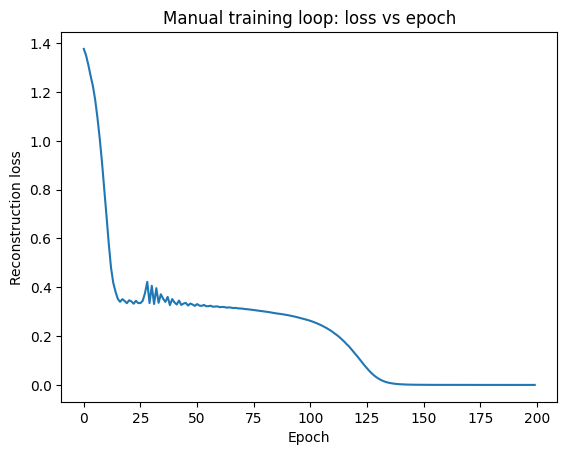

In [261]:
#############
## CELL 16 ##
#############

# Number of passes through the training step.
epochs = 200
loss_history = []

# Repeat one training step many times and monitor progress.
for epoch in range(1, epochs + 1):
    # One downhill move: update model parameters and get current embedding.
    loss, z = train(data, model, negative_samples, optimizer)
    loss_history.append(loss.item())

    # Print occasionally so students can see the trend without too much output.
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | reconstruction loss = {loss.item():.4f}")

# Visual check: the curve should usually trend downward overall.
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("Manual training loop: loss vs epoch")



The loss should drop over time.

---

#### 5.5 Inspect the Learned Embedding

Now that training is complete, we will evaluate what the model learned in three ways:
1. Retrieve the learned embedding `Z` from the trained autoencoder.
2. Use that embedding to reconstruct an estimate of the adjacency matrix and visually inspect how close it is to the true adjacency matrix.
3. Cluster the embedding to see what the resulting graph partition looks like.

Together, these checks tell us whether the embedding captures both edge-reconstruction quality and meaningful community structure.

#### 5.5.1 Retrieve the Final Embeddings
Put the model in inference mode and get the final embeddings.


In [262]:
#############
## CELL 17 ##
#############

# Save the final embedding for reconstruction and clustering checks below.
with torch.no_grad():
    Z = model.encode(data).detach().numpy()

print(f"Embedding matrix shape: {Z.shape}")

# Inspect a few node embeddings directly.
for node_id in [0, 1, 3, 9]:
    print(f"z[{node_id}] = {np.round(Z[node_id], 3)}")

def cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    return float(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v) + 1e-12))

# Compare pairs that ARE edges vs pairs that are NOT edges.
connected_pairs = [(0, 1), (1, 2), (3, 9)]
not_connected_pairs = [(1, 4), (2, 5), (4, 8)]

print("\nConnected node pairs (expect relatively higher similarity):")
for u, v in connected_pairs:
    sim = cosine_similarity(Z[u], Z[v])
    print(f"  ({u}, {v}): cosine similarity = {sim:.3f}")

print("\nNon-connected node pairs (expect relatively lower similarity):")
for u, v in not_connected_pairs:
    sim = cosine_similarity(Z[u], Z[v])
    print(f"  ({u}, {v}): cosine similarity = {sim:.3f}")

Embedding matrix shape: (10, 10)
z[0] = [ 1.328  1.298 -2.803 -1.892 -5.479 -1.884 -2.514  0.136  0.59   4.113]
z[1] = [ 1.699  1.444 -3.403 -3.193 -6.389  0.46  -3.055  1.386 -1.609  4.38 ]
z[3] = [ 0.595  2.421 -0.971  2.289  2.1   -0.437  2.787 -0.407  2.877 -4.184]
z[9] = [-0.18   0.041  0.112  1.125 -0.202 -3.335 -0.017 -1.556  2.726  0.764]

Connected node pairs (expect relatively higher similarity):
  (0, 1): cosine similarity = 0.924
  (1, 2): cosine similarity = 1.000
  (3, 9): cosine similarity = 0.256

Non-connected node pairs (expect relatively lower similarity):
  (1, 4): cosine similarity = -0.540
  (2, 5): cosine similarity = -0.540
  (4, 8): cosine similarity = -0.376


#### 5.5.2 Checking the Reconstructed Adjacency Matrix

Let's reconstruct an approximation to the adjacency matrix from the learned embedding. If the autoencoder trained well, the resulting matrix should be close to the true adjacency matrix.

In [263]:
#############
## CELL 18 ##
#############

from scipy.special import expit  # Sigmoid for numpy arrays

def get_A_hat(model: GAE, data: PyGData) -> np.ndarray:
    # Encode all nodes using the trained model, then decode with sigmoid(ZZ^T).
    with torch.no_grad():
        Z = model.encode(data).detach().numpy()
    return expit(Z @ Z.T)

# 1) Reconstructed adjacency matrix from the learned embedding.
A_hat = get_A_hat(model, data)

# 2) Build A_tilde = A + I so self loops appear as 1's on the diagonal.
A_true = nx.to_numpy_array(pinwheel_graph)
A_tilde = np.clip(A_true + np.eye(A_true.shape[0]), 0, 1)

# 3) Compare reconstructed matrix to A_tilde elementwise.
abs_error = np.abs(A_tilde - A_hat)

print("Reconstructed adjacency matrix A_hat (rounded):")
print(np.round(A_hat, 2))

print("\nAdjacency matrix of A_tilde (A plus self loops):")
print(A_tilde.astype(int))

print("\nAbsolute error |A_tilde - A_hat| (rounded):")
print(np.round(abs_error, 2))

print("\nSummary error metrics:")
print(f"Mean absolute error: {abs_error.mean():.4f}")
print(f"Max absolute error:  {abs_error.max():.4f}")

Reconstructed adjacency matrix A_hat (rounded):
[[1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 1.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 0.]
 [1. 0. 0. 1. 0. 0. 1. 0. 0. 1.]]

Adjacency matrix of A_tilde (A plus self loops):
[[1 1 1 0 0 0 0 0 0 1]
 [1 1 1 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 1]
 [0 0 0 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 1 1 1 0]
 [1 0 0 1 0 0 1 0 0 1]]

Absolute error |A_tilde - A_hat| (rounded):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

The reconstructed matrix is close to the original adjacency matrix, so the embedding is carrying the graph structure. The second question is whether that same embedding also groups structurally similar nodes together, so let's cluster it next.

#### 5.5.3 See how well the embedding clustered

We're using more than two dimensions for the embedding, so we'll use TSNE to compress this to two dimensions before visualizing.

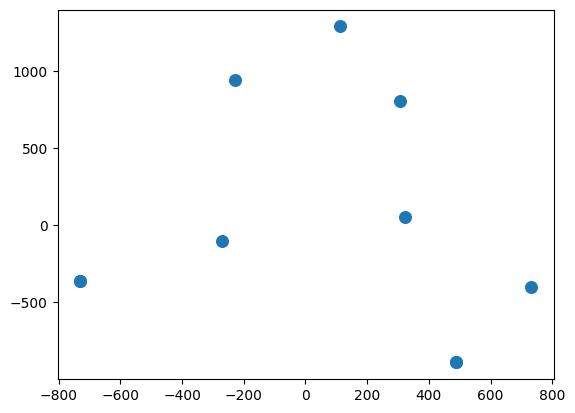

In [264]:
#############
## CELL 19 ##
#############

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(Z):
    z = TSNE(n_components=2, perplexity = 5).fit_transform(Z)
    plt.scatter(z[:, 0], z[:, 1], s=70)
with torch.no_grad():
    Z = model.encode(data).detach().numpy()
visualize(Z)


This shows a pretty good visual separation between node embeddings. Let's cluster on the original encoding to see which nodes belong together.

Cluster and show nodes by cluster color. Try 7 clusters first.

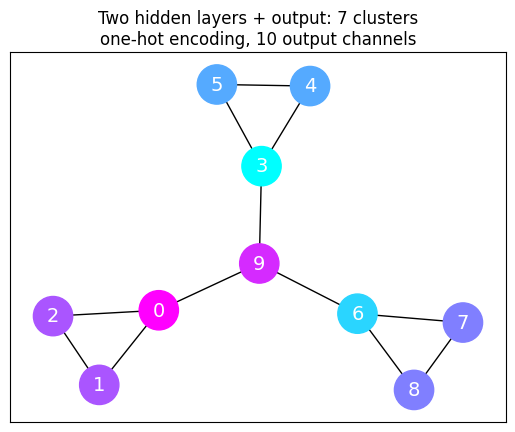

In [265]:
#############
## CELL 20 ##
#############

from sklearn.cluster import KMeans
def get_clusters(Z, num_clusters = 2) -> KMeans:
    kmeans = KMeans(
        init="random",
        n_clusters= num_clusters,
        n_init=10,
        random_state=1234
        )
    return kmeans.fit(Z)

kmeans = get_clusters(Z, num_clusters = 7)

nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 7 clusters\none-hot encoding, 10 output channels")

Now try with four clusters

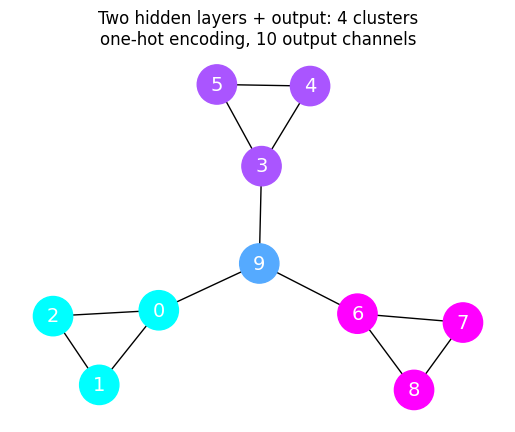

In [266]:
#############
## CELL 21 ##
#############

kmeans = get_clusters(Z, num_clusters = 4)

plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 4 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

The encoding produced by graph autoencoder did a good job of keeping structurally similar nodes together for both 7 clusters and 4 clusters. That's encouraging. 

---

### 6.0 Experiments With Different GAE Architectures

Section 5 kept every learning step out in the open. Now we'll package negative sampling, optimizer setup, and the training loop into a helper class so we can run architecture experiments more cleanly.

#### 6.1 Wrap Training and Negative Sampling in a Helper Class


A key design choice in this class is **negative-edge resampling**. Recall that reconstruction loss compares real edges to sampled non-edges. If we always train against the exact same negative set, the model can overfit to those particular non-edges and get a narrower training signal.

Briefly, **overfitting** means the model gets very good at the specific examples it repeatedly sees during training, but does not generalize as well to new examples.

Resampling periodically exposes the model to a broader set of non-edges, which usually gives a more robust estimate of reconstruction quality.

In `GAETrainingRun.fit(...)`, this behavior is controlled by `resample_each_epoch`:
- `False`: sample once and reuse the same negatives across epochs (faster, more stable comparisons).
- `True`: draw fresh negatives each epoch (broader supervision, often better generalization).

In [267]:
class GAETrainingRun:
    """Helper for running GAE training with configurable negative-edge resampling.

    This class bundles model training state (optimizer, sampled negatives, and loss history)
    so architecture experiments can reuse the same workflow with minimal boilerplate.
    """

    def __init__(self,
                 data: PyGData,
                 model: GAE,
                 feature_attr: str = "x",
                 learning_rate: float = 0.01):
        """Initialize a training run for one data/model pair.

        Args:
            data: PyG graph data object containing edges and features.
            model: GAE model to train.
            feature_attr: Name of node-feature attribute in data (e.g., "x" or "feature").
            learning_rate: Learning rate used by Adam.
        """
        self.data = data
        self.model = model
        self.feature_attr = feature_attr
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.negative_samples = None
        self.loss_history: List[float] = []

    def get_features(self) -> Tensor:
        """Return the node-feature matrix specified by feature_attr."""
        return getattr(self.data, self.feature_attr)

    def resample_negative_samples(self, num_negative_samples: Optional[int] = None) -> Tensor:
        """Draw a new batch of negative edges (non-edges) for reconstruction loss.

        Args:
            num_negative_samples: Number of negative samples to draw. If None,
                uses the helper default (typically matching number of positive edges).

        Returns:
            Tensor of shape [2, num_negative_samples] containing sampled non-edges.
        """
        self.negative_samples = generate_negative_samples(
            self.data.edge_index,
            self.data.num_nodes,
            num_negative_samples
        )
        return self.negative_samples

    def train_step(self) -> Tuple[Tensor, Tensor]:
        """Run one optimization step and return (loss, embedding).

        If no negative samples are currently stored, this method samples them once
        before computing reconstruction loss.
        """
        if self.negative_samples is None:
            self.resample_negative_samples()

        self.optimizer.zero_grad()
        z = self.model.encode(self.get_features(), self.data.edge_index)
        loss = self.model.recon_loss(z, self.data.edge_index, self.negative_samples)
        loss.backward()
        self.optimizer.step()
        return loss, z

    def fit(self,
            epochs: int = 200,
            log_every: int = 10,
            resample_each_epoch: bool = False
            ) -> Tuple[List[float], Tensor]:
        """Train for multiple epochs and return loss history plus last embedding.

        Args:
            epochs: Number of training epochs.
            log_every: Print loss every log_every epochs (0 disables logging).
            resample_each_epoch: If True, draw fresh negative samples each epoch.
                If False, reuse one sampled set across epochs unless missing.

        Returns:
            A tuple (loss_history, z_last).
        """
        self.loss_history = []
        z = None
        for epoch in range(1, epochs + 1):
            if resample_each_epoch or self.negative_samples is None:
                self.resample_negative_samples()
            loss, z = self.train_step()
            self.loss_history.append(loss.item())
            if log_every and epoch % log_every == 0:
                print(f"Loss in epoch {epoch} is {loss.item():.4f}")
        return self.loss_history, z

    def embedding(self) -> np.ndarray:
        """Return current node embeddings as a NumPy array in eval mode."""
        with torch.no_grad():
            z = self.model.encode(self.get_features(), self.data.edge_index).detach().numpy()
        return z

    def reconstructed_adjacency(self) -> np.ndarray:
        """Return reconstructed adjacency estimate A_hat = sigmoid(ZZ^T)."""
        z = self.embedding()
        return expit(z @ z.T)

#### 6.2 Output Layer Only

Let's start with the smallest encoder and see what happens when the model only has a single graph convolutional output layer.

What to expect before running this experiment:
- The model may train quickly, but reconstruction quality is often weaker than with deeper encoders.
- You may see blurrier separation between strong-edge and non-edge probabilities in $\hat{A}$.
- Loss can still decrease, but it may plateau at a higher value.

Why this is a reasonable expectation:
- With only one layer, each node embedding is built from a single round of neighborhood aggregation.
- That limits how much higher-order structure (for example, relationships beyond immediate neighbors) the encoder can represent.
- Deeper encoders can apply multiple graph transformations, which gives the model more capacity to encode patterns needed for adjacency reconstruction.

This makes the one-layer setup a useful baseline: if it already performs well, extra depth may be unnecessary; if it underperforms, the deeper variants in the next subsections should help explain what extra capacity buys us.

In [268]:
class Encoder_With_One_Layer(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder_With_One_Layer, self).__init__()
        self.output_layer = GCNConv(in_channels, out_channels)
    def forward(self, x, edge_index):
        z = self.output_layer(x, edge_index)
        return z

# Delete previous model and instantiate a new one
if 'model' in globals(): 
    del model

model = GAE(Encoder_With_One_Layer(num_features, out_channels))
print(model)


GAE(
  (encoder): Encoder_With_One_Layer(
    (output_layer): GCNConv(10, 10)
  )
  (decoder): InnerProductDecoder()
)


Nothing else needs to change. Let's train the model and inspect $\hat{A}$.

In [269]:
trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=200, log_every=10)

Loss in epoch 10 is 1.1962
Loss in epoch 20 is 1.0093
Loss in epoch 30 is 0.7931
Loss in epoch 40 is 0.5968
Loss in epoch 50 is 0.4533
Loss in epoch 60 is 0.3574
Loss in epoch 70 is 0.2921
Loss in epoch 80 is 0.2451
Loss in epoch 90 is 0.2089
Loss in epoch 100 is 0.1798
Loss in epoch 110 is 0.1555
Loss in epoch 120 is 0.1349
Loss in epoch 130 is 0.1173
Loss in epoch 140 is 0.1023
Loss in epoch 150 is 0.0894
Loss in epoch 160 is 0.0784
Loss in epoch 170 is 0.0691
Loss in epoch 180 is 0.0611
Loss in epoch 190 is 0.0543
Loss in epoch 200 is 0.0484


In [270]:
print(np.round(trainer.reconstructed_adjacency(), 1))

[[1.  1.  1.  0.1 0.  0.  0.4 0.1 0.1 0.9]
 [1.  1.  1.  0.  0.  0.  0.  0.  0.  0.1]
 [1.  1.  1.  0.  0.  0.  0.  0.  0.  0.1]
 [0.1 0.  0.  1.  1.  1.  0.1 0.  0.  0.9]
 [0.  0.  0.  1.  1.  1.  0.  0.  0.  0.1]
 [0.  0.  0.  1.  1.  1.  0.  0.  0.  0.1]
 [0.4 0.  0.  0.1 0.  0.  1.  1.  1.  1. ]
 [0.1 0.  0.  0.  0.  0.  1.  1.  1.  1. ]
 [0.1 0.  0.  0.  0.  0.  1.  1.  1.  1. ]
 [0.9 0.1 0.1 0.9 0.1 0.1 1.  1.  1.  1. ]]


$\hat{A}$ isn't as close to $A$.  Why?


How well do things cluster?

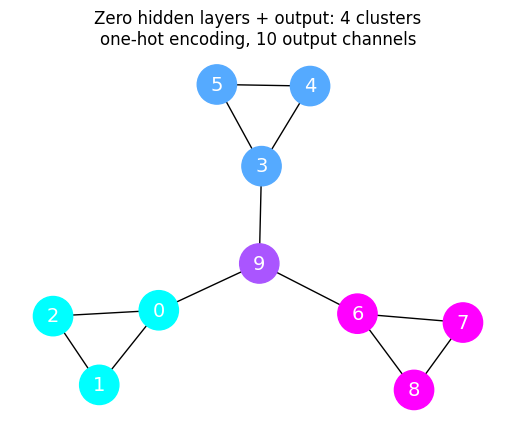

In [271]:
#############
## CELL 22 ##
#############

Z = trainer.embedding()
kmeans = get_clusters(Z, num_clusters = 4)

plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 4 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

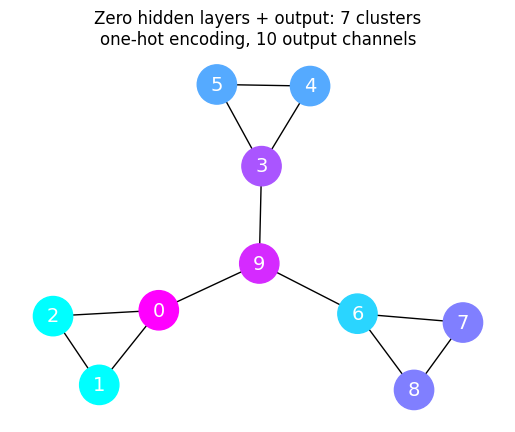

In [272]:
#############
## CELL 23 ##
#############

Z = z.detach().cpu().numpy()
kmeans = get_clusters(Z, num_clusters = 7)

plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 7 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

#### 6.3 One Hidden Layer Plus an Output Layer

In this experiment, we add one hidden layer before the output layer. This gives the encoder an extra nonlinear transformation and one more round of neighborhood mixing.

Student guide: what to look for
- Compare this run directly to Section 6.2 (output layer only), not in isolation.
- Check whether reconstruction loss drops faster or reaches a lower final value.
- Inspect whether $\hat{A}$ shows clearer contrast: true edges closer to 1 and non-edges closer to 0.
- Look for fewer ambiguous mid-range values (around 0.4 to 0.6) in the reconstructed matrix.

Why you might expect improvement
- The hidden layer increases model capacity, so the encoder can represent more complex structural patterns.
- The ReLU nonlinearity allows piecewise nonlinear mappings that a single linear graph-convolution layer cannot express as easily.
- An additional transformation step can separate node roles that looked too similar in the one-layer baseline.

How to interpret outcomes
- If results improve: extra depth is helping represent structure in this graph.
- If results barely change: the graph may already be simple enough that the smaller model was sufficient.
- If results get worse: this can happen from optimization noise, random initialization, or limited epochs; rerunning or training longer can help verify whether the architecture is actually worse.

In [273]:
class Encoder_With_Two_Layers(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder_With_Two_Layers, self).__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 4 * out_channels)
        self.output_layer = GCNConv(4 * out_channels, out_channels)
        
    def forward(self, x, edge_index):
        h1 = self.hidden_layer_1(x, edge_index)
        squashed_h1 = F.relu(h1)     
        z = self.output_layer(squashed_h1, edge_index)
        return z

if 'model' in globals(): 
    del model

model = GAE(Encoder_With_Two_Layers(num_features, out_channels))
print(model)

trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=200, log_every=10)


GAE(
  (encoder): Encoder_With_Two_Layers(
    (hidden_layer_1): GCNConv(10, 40)
    (output_layer): GCNConv(40, 10)
  )
  (decoder): InnerProductDecoder()
)
Loss in epoch 10 is 0.6700
Loss in epoch 20 is 0.2335
Loss in epoch 30 is 0.1310
Loss in epoch 40 is 0.0769
Loss in epoch 50 is 0.0349
Loss in epoch 60 is 0.0138
Loss in epoch 70 is 0.0062
Loss in epoch 80 is 0.0033
Loss in epoch 90 is 0.0021
Loss in epoch 100 is 0.0015
Loss in epoch 110 is 0.0012
Loss in epoch 120 is 0.0010
Loss in epoch 130 is 0.0008
Loss in epoch 140 is 0.0007
Loss in epoch 150 is 0.0006
Loss in epoch 160 is 0.0005
Loss in epoch 170 is 0.0005
Loss in epoch 180 is 0.0004
Loss in epoch 190 is 0.0004
Loss in epoch 200 is 0.0003


In [274]:
print(np.round(trainer.reconstructed_adjacency(), 2))

[[1.   1.   1.   0.01 0.   0.   0.   0.   0.   1.  ]
 [1.   1.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [1.   1.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.01 0.   0.   1.   1.   1.   0.   0.   0.   1.  ]
 [0.   0.   0.   1.   1.   1.   0.   0.   0.   1.  ]
 [0.   0.   0.   1.   1.   1.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.   0.   0.   1.   1.   1.   1.  ]
 [0.   0.   0.   0.   0.   0.   1.   1.   1.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   1.   1.   0.  ]
 [1.   0.   0.   1.   1.   1.   1.   0.   0.   1.  ]]


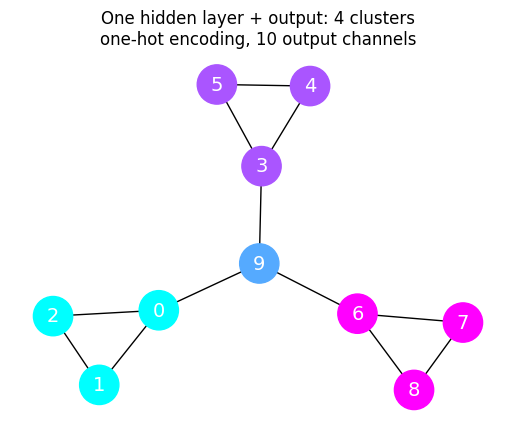

In [275]:
#############
## CELL 24 ##
#############

Z = trainer.embedding()
kmeans = get_clusters(Z, num_clusters = 4)

plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("One hidden layer + output: 4 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

#### 6.4 Change the Embedding Width

Next, keep the shallow encoder but squeeze the embedding dimension to see how much width matters.

Guidelines for what to expect in this experiment:
- With a very small embedding (for example, 2 dimensions), reconstruction usually gets harder because many node relationships must be compressed into very little space.
- As width increases (for example, 3 or more), $\hat{A}$ often becomes cleaner and closer to the target structure.
- Training may still reduce loss at small width, but it can plateau earlier because the representation is capacity-limited.

Why this happens:
- Embedding width is the number of coordinates each node gets to represent its structural role.
- Fewer coordinates force stronger information bottlenecks, so distinct neighborhoods can become harder to separate.
- More coordinates increase expressive capacity, but also add parameters and can make interpretation less direct.

How to read the results in this section:
- Compare the reconstructed matrices across widths, not just one run in isolation.
- Watch whether edge probabilities for true edges separate more clearly from non-edges as width changes.
- Use the longer-training rerun as a check for under-training versus true capacity limits (if performance stays weak even after more epochs, width is likely the main constraint).

In [276]:
out_channels = 2
num_features = data.num_features
if 'model' in globals(): 
    del model

model = GAE(Encoder_With_One_Layer(num_features, out_channels))
print(model)

trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=200, log_every=20)

GAE(
  (encoder): Encoder_With_One_Layer(
    (output_layer): GCNConv(10, 2)
  )
  (decoder): InnerProductDecoder()
)
Loss in epoch 20 is 1.2721
Loss in epoch 40 is 1.1136
Loss in epoch 60 is 0.9172
Loss in epoch 80 is 0.7484
Loss in epoch 100 is 0.6284
Loss in epoch 120 is 0.5430
Loss in epoch 140 is 0.4814
Loss in epoch 160 is 0.4378
Loss in epoch 180 is 0.4072
Loss in epoch 200 is 0.3855


In [277]:
print(np.round(trainer.reconstructed_adjacency(), 2))

[[0.96 0.98 0.98 0.18 0.22 0.22 0.05 0.05 0.05 0.37]
 [0.98 1.   1.   0.05 0.07 0.07 0.04 0.05 0.05 0.3 ]
 [0.98 1.   1.   0.05 0.07 0.07 0.04 0.05 0.05 0.3 ]
 [0.18 0.05 0.05 0.99 0.99 0.99 0.29 0.1  0.1  0.74]
 [0.22 0.07 0.07 0.99 0.99 0.99 0.28 0.1  0.1  0.72]
 [0.22 0.07 0.07 0.99 0.99 0.99 0.28 0.1  0.1  0.72]
 [0.05 0.04 0.04 0.29 0.28 0.28 0.98 0.99 0.99 0.52]
 [0.05 0.05 0.05 0.1  0.1  0.1  0.99 1.   1.   0.46]
 [0.05 0.05 0.05 0.1  0.1  0.1  0.99 1.   1.   0.46]
 [0.37 0.3  0.3  0.74 0.72 0.72 0.52 0.46 0.46 0.56]]


If we are clever we can see a structure. What if we train longer?


In [278]:
out_channels = 2
num_features = data.num_features
if 'model' in globals(): 
    del model

model = GAE(Encoder_With_One_Layer(num_features, out_channels))
print(model)

trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=600, log_every=20)

GAE(
  (encoder): Encoder_With_One_Layer(
    (output_layer): GCNConv(10, 2)
  )
  (decoder): InnerProductDecoder()
)
Loss in epoch 20 is 1.2961
Loss in epoch 40 is 1.1445
Loss in epoch 60 is 0.9451
Loss in epoch 80 is 0.7616
Loss in epoch 100 is 0.6192
Loss in epoch 120 is 0.5151
Loss in epoch 140 is 0.4457
Loss in epoch 160 is 0.4013
Loss in epoch 180 is 0.3720
Loss in epoch 200 is 0.3518
Loss in epoch 220 is 0.3375
Loss in epoch 240 is 0.3269
Loss in epoch 260 is 0.3188
Loss in epoch 280 is 0.3123
Loss in epoch 300 is 0.3070
Loss in epoch 320 is 0.3026
Loss in epoch 340 is 0.2987
Loss in epoch 360 is 0.2953
Loss in epoch 380 is 0.2922
Loss in epoch 400 is 0.2894
Loss in epoch 420 is 0.2868
Loss in epoch 440 is 0.2843
Loss in epoch 460 is 0.2820
Loss in epoch 480 is 0.2796
Loss in epoch 500 is 0.2774
Loss in epoch 520 is 0.2751
Loss in epoch 540 is 0.2729
Loss in epoch 560 is 0.2706
Loss in epoch 580 is 0.2683
Loss in epoch 600 is 0.2661


How'd we do?

In [279]:
print(np.round(trainer.reconstructed_adjacency(), 2))

[[1.   1.   1.   0.12 0.   0.   0.04 0.   0.   0.79]
 [1.   1.   1.   0.34 0.03 0.03 0.01 0.   0.   0.71]
 [1.   1.   1.   0.34 0.03 0.03 0.01 0.   0.   0.71]
 [0.12 0.34 0.34 0.95 0.99 0.99 0.01 0.02 0.02 0.33]
 [0.   0.03 0.03 0.99 1.   1.   0.   0.02 0.02 0.19]
 [0.   0.03 0.03 0.99 1.   1.   0.   0.02 0.02 0.19]
 [0.04 0.01 0.01 0.01 0.   0.   1.   1.   1.   0.65]
 [0.   0.   0.   0.02 0.02 0.02 1.   1.   1.   0.53]
 [0.   0.   0.   0.02 0.02 0.02 1.   1.   1.   0.53]
 [0.79 0.71 0.71 0.33 0.19 0.19 0.65 0.53 0.53 0.56]]


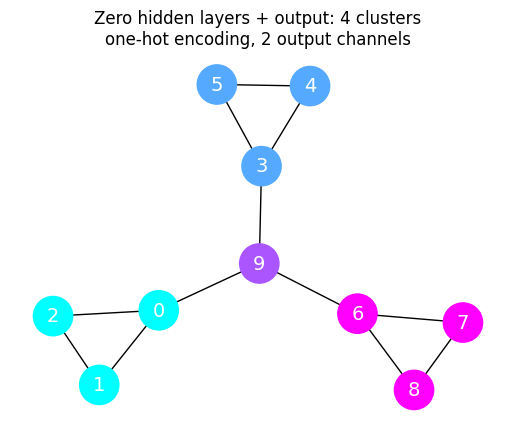

In [280]:
#############
## CELL 25 ##
#############

Z = z.detach().cpu().numpy()
kmeans = get_clusters(Z, num_clusters = 4)

plt.figure()
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 4 clusters\none-hot encoding, 2 output channels")
_ = plt.axis('off')

#### 6.5 What if the embedding has three dimensions instead of two?

Student guide: what to look for
- Compare this run to both earlier 2D runs: 200 epochs and 600 epochs.
- Check whether adding one more dimension improves $\hat{A}$ more than simply training longer in 2D.
- Look for sharper edge/non-edge separation in reconstructed entries (fewer uncertain middle values).
- Note whether the loss trajectory appears to settle at a lower level than the 2D, 200-epoch case.

Why this comparison matters
- Going from 2D to 3D increases representational capacity with only a small increase in complexity.
- If 3D at 200 epochs outperforms 2D at 600 epochs, capacity (not training time) was likely the main bottleneck.
- If 3D and long-trained 2D are similar, then optimization time may be as important as embedding width for this graph.

How to conclude this section
- Decide whether width or training duration gave the bigger improvement.
- Record one concrete observation from $\hat{A}$ (for example, which block/pattern became clearer).
- Use that conclusion to motivate the next depth experiment.

In [281]:
out_channels = 3
num_features = data.num_features
if 'model' in globals(): 
    del model

model = GAE(Encoder_With_One_Layer(num_features, out_channels))
print(model)

trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=200, log_every=20)

GAE(
  (encoder): Encoder_With_One_Layer(
    (output_layer): GCNConv(10, 3)
  )
  (decoder): InnerProductDecoder()
)
Loss in epoch 20 is 1.2538
Loss in epoch 40 is 1.0457
Loss in epoch 60 is 0.7963
Loss in epoch 80 is 0.6017
Loss in epoch 100 is 0.4813
Loss in epoch 120 is 0.4054
Loss in epoch 140 is 0.3510
Loss in epoch 160 is 0.3080
Loss in epoch 180 is 0.2715
Loss in epoch 200 is 0.2393


In [282]:
print(np.round(trainer.reconstructed_adjacency(), 2))

[[1.   1.   1.   0.13 0.05 0.05 0.14 0.05 0.05 0.79]
 [1.   1.   1.   0.07 0.06 0.06 0.03 0.02 0.02 0.52]
 [1.   1.   1.   0.07 0.06 0.06 0.03 0.02 0.02 0.52]
 [0.13 0.07 0.07 0.99 0.99 0.99 0.17 0.1  0.1  0.63]
 [0.05 0.06 0.06 0.99 1.   1.   0.04 0.04 0.04 0.31]
 [0.05 0.06 0.06 0.99 1.   1.   0.04 0.04 0.04 0.31]
 [0.14 0.03 0.03 0.17 0.04 0.04 1.   1.   1.   0.82]
 [0.05 0.02 0.02 0.1  0.04 0.04 1.   1.   1.   0.58]
 [0.05 0.02 0.02 0.1  0.04 0.04 1.   1.   1.   0.58]
 [0.79 0.52 0.52 0.63 0.31 0.31 0.82 0.58 0.58 0.86]]


#### 6.6 Three Hidden Layers and One Output Layer

Finally, increase depth to a deeper encoder with **three hidden layers plus one output layer** and see whether it helps or mainly adds complexity on this small graph.

Student guide: what to look for
- Compare this result to Section 6.3 (one hidden layer + output), using both loss and reconstructed $\hat{A}$.
- Do not assume deeper is better: check whether edge/non-edge separation actually improves in a meaningful way.
- Watch for diminishing returns: similar reconstruction quality with more layers means extra depth is not buying much here.

Why we might *not* expect clear improvement on this graph
- The pinwheel graph is small and structurally simple, so a shallower encoder may already capture most useful patterns.
- Extra layers increase parameter count and optimization complexity without adding much new signal.
- More depth can also oversmooth node representations, making different nodes look too similar.

Overfitting risk: when it matters more
- On this tiny graph, overfitting risk exists but may be less obvious because there is limited variation to begin with.
- Overfitting becomes a bigger concern on graphs with noisy edges, weak community structure, high heterogeneity, or many idiosyncratic local motifs.
- In those settings, a deep model may memorize quirks of sampled edges/non-edges instead of learning robust structure.

How to interpret outcomes
- If performance is similar to 6.3, prefer the simpler model (better parsimony and easier interpretation).
- If performance gets worse, that supports the idea that added depth introduced unnecessary complexity.
- If performance improves, note how large the improvement is and whether it justifies the added model complexity.

In [283]:
class Encoder_ThreeHiddenOneOutput(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder_ThreeHiddenOneOutput, self).__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 8 * out_channels)
        self.hidden_layer_2 = GCNConv(8 * out_channels, 4 * out_channels)
        self.hidden_layer_3 = GCNConv(4 * out_channels, 2 * out_channels)
        self.output_layer = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        h1 = F.relu(self.hidden_layer_1(x, edge_index))
        h2 = F.relu(self.hidden_layer_2(h1, edge_index))
        h3 = F.relu(self.hidden_layer_3(h2, edge_index))
        z = self.output_layer(h3, edge_index)
        return z

out_channels = 10
num_features = data.num_features
if 'model' in globals():
    del model

model = GAE(Encoder_ThreeHiddenOneOutput(num_features, out_channels))
print(model)
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameter count: {num_trainable_params}")

trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = trainer.fit(epochs=200, log_every=10)

GAE(
  (encoder): Encoder_ThreeHiddenOneOutput(
    (hidden_layer_1): GCNConv(10, 80)
    (hidden_layer_2): GCNConv(80, 40)
    (hidden_layer_3): GCNConv(40, 20)
    (output_layer): GCNConv(20, 10)
  )
  (decoder): InnerProductDecoder()
)
Trainable parameter count: 5150
Loss in epoch 10 is 0.4711
Loss in epoch 20 is 0.2587
Loss in epoch 30 is 0.1801
Loss in epoch 40 is 0.1239
Loss in epoch 50 is 0.0579
Loss in epoch 60 is 0.0110
Loss in epoch 70 is 0.0023
Loss in epoch 80 is 0.0007
Loss in epoch 90 is 0.0003
Loss in epoch 100 is 0.0002
Loss in epoch 110 is 0.0002
Loss in epoch 120 is 0.0001
Loss in epoch 130 is 0.0001
Loss in epoch 140 is 0.0001
Loss in epoch 150 is 0.0001
Loss in epoch 160 is 0.0001
Loss in epoch 170 is 0.0001
Loss in epoch 180 is 0.0001
Loss in epoch 190 is 0.0001
Loss in epoch 200 is 0.0001


In [284]:
print(np.round(trainer.reconstructed_adjacency(), 2))

[[1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 1.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 1. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [1. 0. 0. 1. 0. 0. 1. 1. 1. 1.]]


#### 6.6.1 Show partition based on clustering and check if it biases toward regular equivalence

After section 6.6.1, add cells that put model in inference mode, retrieves embedding, clusters with 2, 3, and 4 groups, and shows partitioning using the pattern in cells 20 and 21. I want to check whether more hidden layers biases clusteering towards regularly equivalent nodes in contrast to structurally equivalent node clustering

Retrieve the embedding from the deeper encoder in inference mode, then cluster it with 2, 3, and 4 groups so we can compare whether the deeper architecture is grouping structurally equivalent nodes or drifting toward regular equivalence.

In [285]:
#############
## CELL A1 ##
#############

model.eval()

with torch.no_grad():
    Z = model.encode(data.x, data.edge_index).detach().numpy()

print(f"Embedding matrix shape: {Z.shape}")
for node_id in range(len(Z)):
    print(f"z[{node_id}] = {np.round(Z[node_id], 3)}")

Embedding matrix shape: (10, 10)
z[0] = [ 1.602  3.993 -0.751  0.042 -0.156  2.627 -0.61   3.767  0.566  0.554]
z[1] = [ 2.906  4.796  0.36  -0.426 -0.1    2.251  0.263  3.819  1.448  0.023]
z[2] = [ 2.906  4.796  0.36  -0.426 -0.1    2.251  0.263  3.819  1.448  0.023]
z[3] = [-1.371 -1.266 -0.567  4.152  3.325 -2.707  0.641  1.769  1.278 -0.381]
z[4] = [-0.528 -1.275  0.573  4.32   3.919 -3.908  1.708  1.512  2.27  -1.057]
z[5] = [-0.528 -1.275  0.573  4.32   3.919 -3.908  1.708  1.512  2.27  -1.057]
z[6] = [-10.921  -5.313 -10.955   1.987  -2.26    6.693  -9.097  -0.184  -9.223
   5.687]
z[7] = [-11.555  -5.949 -11.422   1.819  -2.53    6.946  -9.536  -0.743  -9.857
   5.951]
z[8] = [-11.555  -5.949 -11.422   1.819  -2.53    6.946  -9.536  -0.743  -9.857
   5.951]
z[9] = [-3.494 -0.73  -3.994  2.013  0.212  2.154 -2.981  1.791 -2.422  1.946]


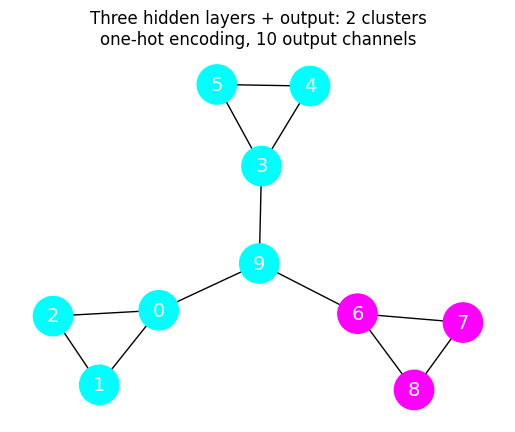

In [286]:
#############
## CELL A2 ##
#############

kmeans = get_clusters(Z, num_clusters=2)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 2 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

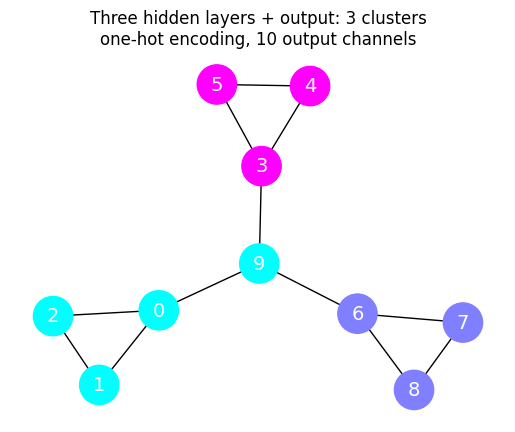

In [287]:
#############
## CELL A3 ##
#############

kmeans = get_clusters(Z, num_clusters=3)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 3 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

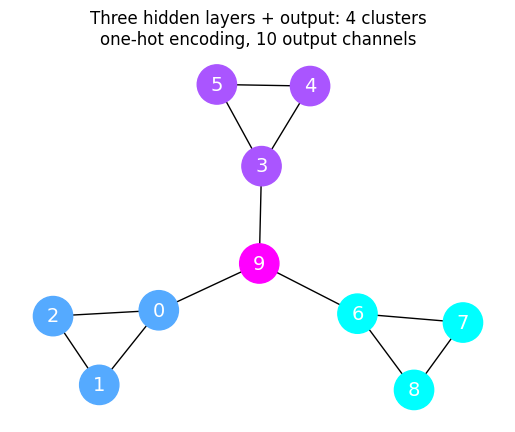

In [288]:
#############
## CELL A4 ##
#############

kmeans = get_clusters(Z, num_clusters=4)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 4 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

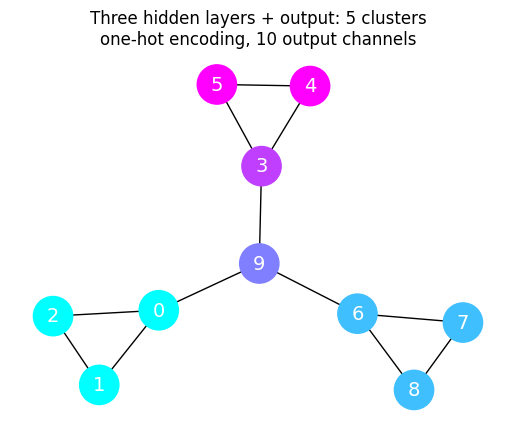

In [289]:
#############
## CELL A5 ##
#############

kmeans = get_clusters(Z, num_clusters=5)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 5 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

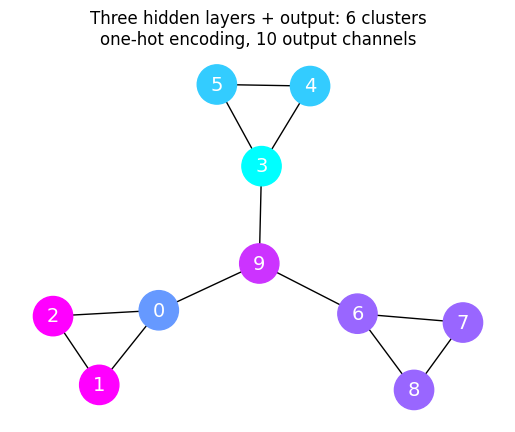

In [290]:
#############
## CELL A6 ##
#############

kmeans = get_clusters(Z, num_clusters=6)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 6 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

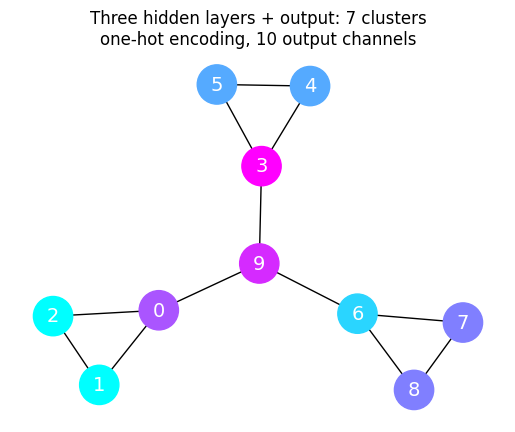

In [291]:
#############
## CELL A6 ##
#############

kmeans = get_clusters(Z, num_clusters=7)

plt.figure()
nx.draw_networkx(pinwheel_graph,
                 pos=nx.nx_pydot.graphviz_layout(pinwheel_graph, prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Three hidden layers + output: 7 clusters\none-hot encoding, 10 output channels")
_ = plt.axis('off')

---
---

### 7.0 Repeat the Workflow with Simulated Features

Now we'll repeat the core ideas from previous sections, but use simulated node features instead of one-hot encoding. To match common PyTorch Geometric usage, we'll store the node feature vector under the attribute name `x`, so the converted PyG `Data` object uses the standard `data.x` field for node features.

In [292]:
#############
## Cell B1 ##
#############

pinwheel_graph: nx.Graph = nx.Graph()
for i in range(0,10):  # give each node a simulated feature vector
    if i in {1,2,4,5,7,8}:
        pinwheel_graph.add_node(i, x=[i+1, 0.0, 0.0])
    elif i in {0,3,6}:
        pinwheel_graph.add_node(i, x=[0.0, i+1, 0.0])
    else:
        pinwheel_graph.add_node(i, x=[0.0, 0.0, i+1])
pinwheel_graph.add_edges_from([(0,1),(0,2),(1,2),(3,4),(3,5),(4,5),(6,7),(6,8),(7,8),(0,9),(3,9),(6,9)])
pinwheel_graph.add_edges_from([(0,0),(1,1),(2,2),(3,3),(4,4),(5,5),(6,6),(7,7),(8,8),(9,9)])
data: PyGData = from_networkx(pinwheel_graph)      # convert to pytorch data structure
print(f"Pinwheel graph as pytorch data structure is\n\t {data}")
print(f"feature vector is:\n{data.x}")

Pinwheel graph as pytorch data structure is
	 Data(x=[10, 3], edge_index=[2, 34])
feature vector is:
tensor([[ 0.,  1.,  0.],
        [ 2.,  0.,  0.],
        [ 3.,  0.,  0.],
        [ 0.,  4.,  0.],
        [ 5.,  0.,  0.],
        [ 6.,  0.,  0.],
        [ 0.,  7.,  0.],
        [ 8.,  0.,  0.],
        [ 9.,  0.,  0.],
        [ 0.,  0., 10.]])


Because we named the node attribute `x` before converting from NetworkX, the simulated feature matrix now lands in the standard PyTorch Geometric field `data.x`. That means the encoder can use the same `x, edge_index` interface as the earlier sections.

In [293]:
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 4 * out_channels)
        self.hidden_layer_2 = GCNConv(4 * out_channels, 2 * out_channels)
        self.output = GCNConv(2 * out_channels, out_channels)

    def forward(self, x, edge_index):
        h1 = self.hidden_layer_1(x, edge_index)
        squashed_h1 = F.relu(h1)
        h2 = self.hidden_layer_2(squashed_h1, edge_index)
        squashed_h2 = F.relu(h2)
        z = self.output(squashed_h2, edge_index)
        return z

# parameters
out_channels = 10
num_features = data.x.shape[1]
print(f"There are {num_features} features")
if 'model' in globals():
    del model
model = GAE(Encoder(num_features, out_channels))
print(model)

There are 3 features
GAE(
  (encoder): Encoder(
    (hidden_layer_1): GCNConv(3, 40)
    (hidden_layer_2): GCNConv(40, 20)
    (output): GCNConv(20, 10)
  )
  (decoder): InnerProductDecoder()
)


In [294]:
feature_trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = feature_trainer.fit(epochs=200, log_every=10)

Loss in epoch 10 is 1.1917
Loss in epoch 20 is 0.8981
Loss in epoch 30 is 0.8701
Loss in epoch 40 is 0.8495
Loss in epoch 50 is 0.8249
Loss in epoch 60 is 0.8011
Loss in epoch 70 is 0.7768
Loss in epoch 80 is 0.7529
Loss in epoch 90 is 0.7115
Loss in epoch 100 is 0.6467
Loss in epoch 110 is 0.5033
Loss in epoch 120 is 0.3537
Loss in epoch 130 is 0.3073
Loss in epoch 140 is 0.2964
Loss in epoch 150 is 0.2907
Loss in epoch 160 is 0.2823
Loss in epoch 170 is 0.2663
Loss in epoch 180 is 0.2253
Loss in epoch 190 is 0.1549
Loss in epoch 200 is 0.0281


Inspect the embedding learned from the simulated feature vectors stored in `data.x`.

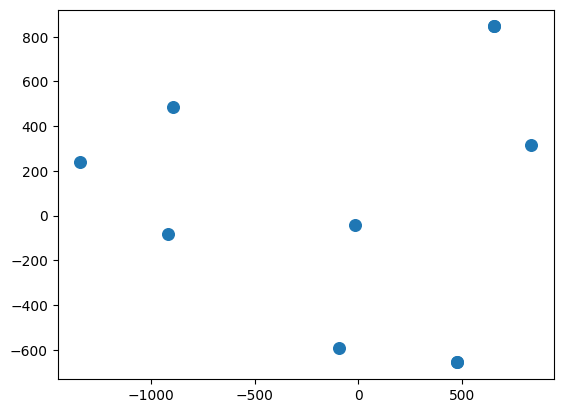

In [295]:
Z = feature_trainer.embedding()
visualize(Z)

Inspect the approximation to the adjacency matrix when the encoder is driven by the simulated node features in `data.x`.

In [296]:
A_hat = feature_trainer.reconstructed_adjacency()
print(np.round(A_hat, 1))

[[1.  1.  1.  0.  0.  0.  0.  0.  0.  1. ]
 [1.  1.  1.  0.  0.  0.  0.  0.  0.  0. ]
 [1.  1.  1.  0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  1.  1.  1.  0.  0.  0.  1. ]
 [0.  0.  0.  1.  1.  1.  0.  0.  0.  0.1]
 [0.  0.  0.  1.  1.  1.  0.  0.  0.  0.1]
 [0.  0.  0.  0.  0.  0.  1.  1.  1.  1. ]
 [0.  0.  0.  0.  0.  0.  1.  1.  1.  0. ]
 [0.  0.  0.  0.  0.  0.  1.  1.  1.  0. ]
 [1.  0.  0.  1.  0.1 0.1 1.  0.  0.  1. ]]


Cluster the feature-based embedding. First, try 7 clusters.

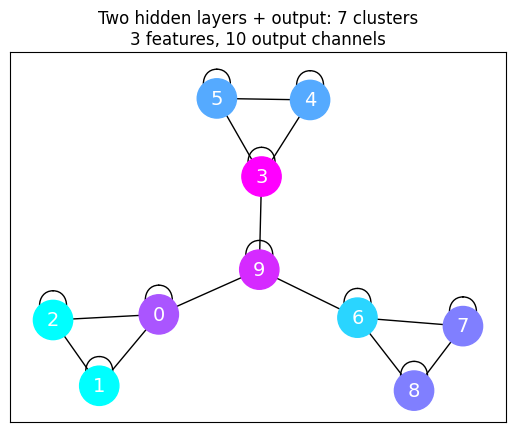

In [297]:
#############
## Cell B2 ##
#############

kmeans = get_clusters(Z, num_clusters = 7)
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 7 clusters\n3 features, 10 output channels")

And now try fewer clusters.

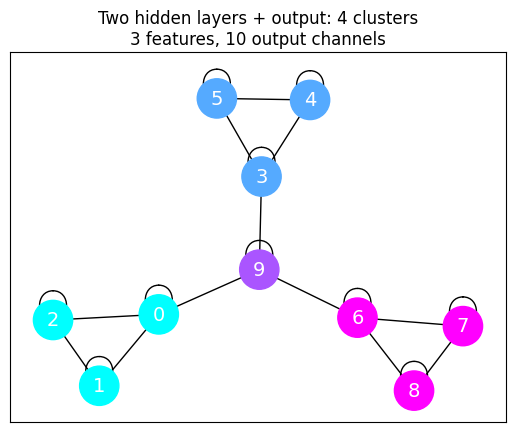

In [298]:
#############
## Cell B3 ##
#############

kmeans = get_clusters(Z, num_clusters = 4)
#print(kmeans.labels_)
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 4 clusters\n3 features, 10 output channels")

We can also rerun the `data.x`-based experiment with a single-layer encoder to see how much the simulated feature information helps.

In [299]:
#############
## Cell B4 ##
#############

class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.output_layer = GCNConv(in_channels, 4 * out_channels)

    def forward(self, x, edge_index):
        z = self.output_layer(x, edge_index)
        return z

# parameters
out_channels = 10
num_features = data.x.shape[1]
print(f"There are {num_features} features")
if 'model' in globals():
    del model
model = GAE(Encoder(num_features, out_channels))
print(model)

There are 3 features
GAE(
  (encoder): Encoder(
    (output_layer): GCNConv(3, 40)
  )
  (decoder): InnerProductDecoder()
)


Loss in epoch 20 is 2.3042
Loss in epoch 40 is 1.2194
Loss in epoch 60 is 1.0487
Loss in epoch 80 is 0.9404
Loss in epoch 100 is 0.8530
Loss in epoch 120 is 0.7921
Loss in epoch 140 is 0.7533
Loss in epoch 160 is 0.7282
Loss in epoch 180 is 0.7115
Loss in epoch 200 is 0.7003


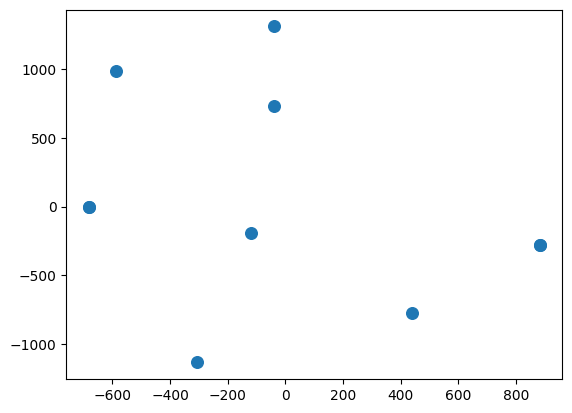

In [300]:
feature_trainer = GAETrainingRun(data, model, learning_rate=0.01)
loss_history, z = feature_trainer.fit(epochs=200, log_every=20)

Z = feature_trainer.embedding()
visualize(Z)

In [301]:
print(np.round(feature_trainer.reconstructed_adjacency(), 1))

[[1.  1.  1.  0.6 0.4 0.4 0.1 0.  0.  1. ]
 [1.  1.  1.  0.5 0.5 0.5 0.  0.  0.  0. ]
 [1.  1.  1.  0.5 0.5 0.5 0.  0.  0.  0. ]
 [0.6 0.5 0.5 0.6 0.4 0.4 0.5 0.4 0.4 1. ]
 [0.4 0.5 0.5 0.4 0.5 0.5 0.5 0.6 0.6 0. ]
 [0.4 0.5 0.5 0.4 0.5 0.5 0.5 0.6 0.6 0. ]
 [0.1 0.  0.  0.5 0.5 0.5 0.9 1.  1.  1. ]
 [0.  0.  0.  0.4 0.6 0.6 1.  1.  1.  0.1]
 [0.  0.  0.  0.4 0.6 0.6 1.  1.  1.  0.1]
 [1.  0.  0.  1.  0.  0.  1.  0.1 0.1 1. ]]


Inspect graph to see if the feature structure provided strong enough semantic information to overcome the deficiency of having only a single linear layer in the encoder.

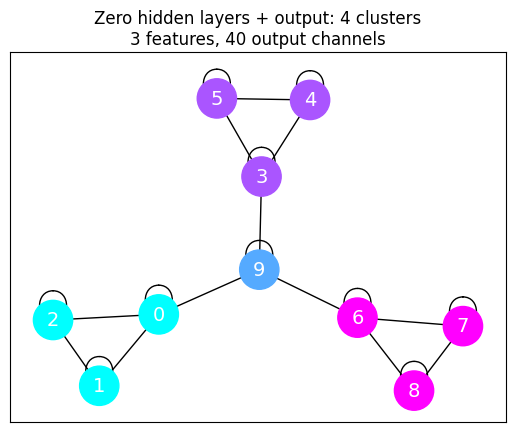

In [302]:
kmeans = get_clusters(Z, num_clusters = 4)
#print(kmeans.labels_)
nx.draw_networkx(pinwheel_graph, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(pinwheel_graph,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 4 clusters\n3 features, 40 output channels")

---

### 8.0 Graph Autoencoder for the Karate Graph

Let's see what kind of clustering we get on the karate club graph

In [303]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')

Dataset: KarateClub():
Number of graphs: 1


This dataset only has one graph, so let's use the data from that graph. We'll begin by inspecting the data object.

In [304]:
data: PyGData = dataset[0]
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


Each data object has x, edge_index, and y. Some have other information like the masks.  
- x contains _node features_. The first index is the number of nodes, and the second index is the number of features. The cora database which we'll explore later has 2708 nodes each with a feature vector with 1433 components. The karate graph has 34 nodes and 34 features, discussed in the next cell.
- y contains _node labels_. If our goal is to classify nodes then it helps to have some of the nodes labeled.
- edge_index has _graph connectivity_. This is essentially the edge set of the graph. The first index contains the ordered edge pair. The second index is the number of edges. Each edge is directed, which means that an undirected graph with an edge $\{u,v\}$ appears twice in the edge_index: once as $(u,v)$ and again as $(v,u)$.



We'll use the one-hot encoding found in the karate club data.

In [305]:
for node in [0,1,2,32,33]:
    print(f'Features 0-9 of node {node}: \t{data.x[node][0:10]}')
    #print(f'Features 10-19 of node {node}: \t{data.x[node][10:20]}')
    #print(f'Features 20-29 of node {node}: \t{data.x[node][20:30]}')
    print(f'Features 30-34 of node {node}: \t{data.x[node][30:34]}')
    print('-----------------------')

Features 0-9 of node 0: 	tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Features 30-34 of node 0: 	tensor([0., 0., 0., 0.])
-----------------------
Features 0-9 of node 1: 	tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
Features 30-34 of node 1: 	tensor([0., 0., 0., 0.])
-----------------------
Features 0-9 of node 2: 	tensor([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])
Features 30-34 of node 2: 	tensor([0., 0., 0., 0.])
-----------------------
Features 0-9 of node 32: 	tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Features 30-34 of node 32: 	tensor([0., 0., 1., 0.])
-----------------------
Features 0-9 of node 33: 	tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Features 30-34 of node 33: 	tensor([0., 0., 0., 1.])
-----------------------


Let's build a graph autoencoder for this graph. We'll ignore the class labels on the nodes. We'll use those in the next tutorial.

In [306]:
#############
## Cell C1 ##
#############

class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.hidden_layer_1 = GCNConv(in_channels, 8 * out_channels)
        self.hidden_layer_2 = GCNConv(8 * out_channels, 4 * out_channels)        
        self.output = GCNConv(4 * out_channels, out_channels)
    def forward(self, x, edge_index):
        h1 = self.hidden_layer_1(x, edge_index)
        h1 = F.relu(h1)
        h2 = self.hidden_layer_2(h1, edge_index)
        h2 = F.relu(h2)
        z = self.output(h2, edge_index)
        return z

In [307]:
# parameters
out_channels = 10
num_features = torch.Tensor.size(data.x)[1]
print(num_features)
if 'model' in globals(): 
    del model
model = GAE(Encoder(num_features, out_channels))
print(model)

34
GAE(
  (encoder): Encoder(
    (hidden_layer_1): GCNConv(34, 80)
    (hidden_layer_2): GCNConv(80, 40)
    (output): GCNConv(40, 10)
  )
  (decoder): InnerProductDecoder()
)


In [308]:
# Generate negative samples using existing utility
# Match the number of negative samples to the number of positive samples.

from torch_geometric.utils import negative_sampling

# Assume data.edge_index contains your positive edges
neg_edge_index = negative_sampling(
    edge_index=data.edge_index,       # existing edges
    num_nodes=data.num_nodes,         # number of nodes
    num_neg_samples=data.edge_index.size(1)  # match # of positive samples
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def train(data: PyGData, 
          model: GAE,
          negative_samples: Tensor,
          optimizer: torch.optim.Optimizer
          ) -> Tuple[Tensor, Tensor]:
    optimizer.zero_grad()  # Clear gradients.
    z = model.encode(data.x, data.edge_index)  # Perform a single forward pass.
    loss = model.recon_loss(z, data.edge_index, negative_samples) # Compute reconstruction loss using positive and negative edges.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, z

epochs = 1000
for epoch in range(1, epochs):
    loss, z = train(data, model, neg_edge_index, optimizer)
    if epoch%20 == 0:
        print(f"Loss in epoch {epoch} is {loss.item()}")

Loss in epoch 20 is 0.957101583480835
Loss in epoch 40 is 0.875549852848053
Loss in epoch 60 is 0.8437092900276184
Loss in epoch 80 is 0.8070845007896423
Loss in epoch 100 is 0.7297430038452148
Loss in epoch 120 is 0.6518820524215698
Loss in epoch 140 is 0.5959745645523071
Loss in epoch 160 is 0.5471078157424927
Loss in epoch 180 is 0.5032493472099304
Loss in epoch 200 is 0.45542746782302856
Loss in epoch 220 is 0.40513357520103455
Loss in epoch 240 is 0.5451585650444031
Loss in epoch 260 is 0.39529237151145935
Loss in epoch 280 is 0.32968607544898987
Loss in epoch 300 is 0.2883433401584625
Loss in epoch 320 is 0.2537224292755127
Loss in epoch 340 is 0.2238619327545166
Loss in epoch 360 is 0.27872344851493835
Loss in epoch 380 is 0.24102053046226501
Loss in epoch 400 is 0.2028515785932541
Loss in epoch 420 is 0.18559174239635468
Loss in epoch 440 is 0.172782763838768
Loss in epoch 460 is 0.16271907091140747
Loss in epoch 480 is 0.15399958193302155
Loss in epoch 500 is 0.146182000637054

Inspect the embedding

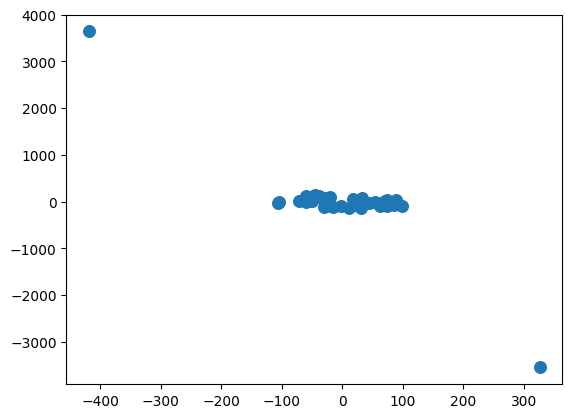

In [309]:
model.eval()
with torch.no_grad():
    Z = model.encode(data.x, data.edge_index).detach().numpy()
visualize(Z)

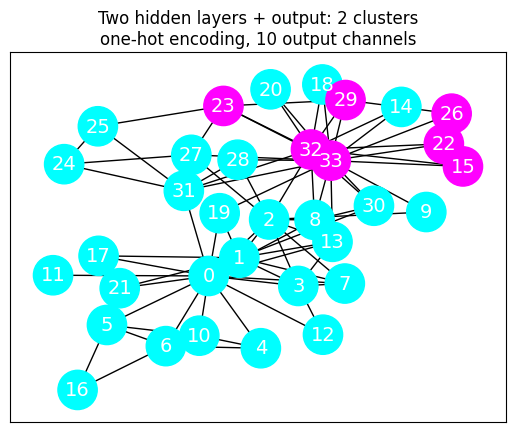

In [310]:
kmeans = get_clusters(Z, num_clusters = 2)

G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 2 clusters\none-hot encoding, 10 output channels")

and if we look at more clusters?

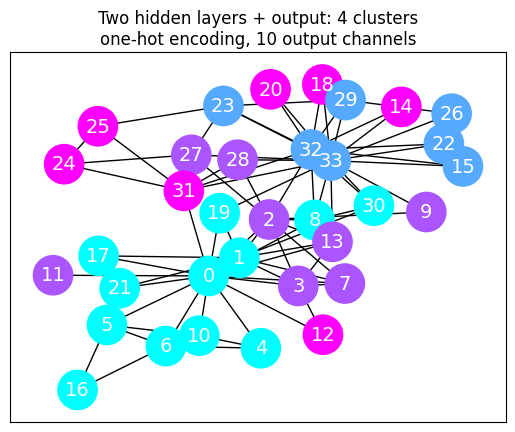

In [311]:
kmeans = get_clusters(Z, num_clusters = 4)

G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 4 clusters\none-hot encoding, 10 output channels")

This is very similar to what we've seen before. What happens if we change to an embedding dimension of 2?

In [312]:
out_channels = 2
num_features = torch.Tensor.size(data.x)[1]
print(num_features)
if 'model' in globals(): 
    del model
model = GAE(Encoder(num_features, out_channels))
print(model)

34
GAE(
  (encoder): Encoder(
    (hidden_layer_1): GCNConv(34, 16)
    (hidden_layer_2): GCNConv(16, 8)
    (output): GCNConv(8, 2)
  )
  (decoder): InnerProductDecoder()
)


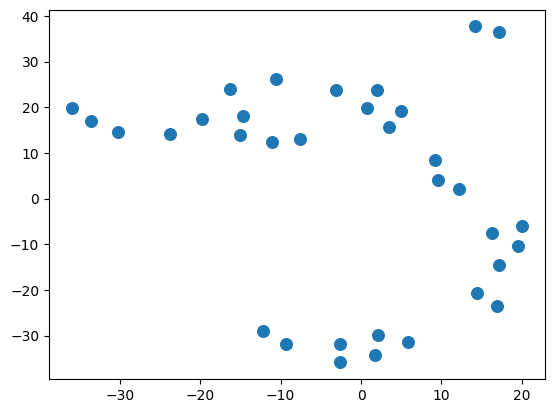

In [313]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 1000
for epoch in range(1, epochs):
    z = train(data, model, neg_edge_index, optimizer)
model.eval()
with torch.no_grad():
    Z = model.encode(data.x, data.edge_index).detach().numpy()
visualize(Z)

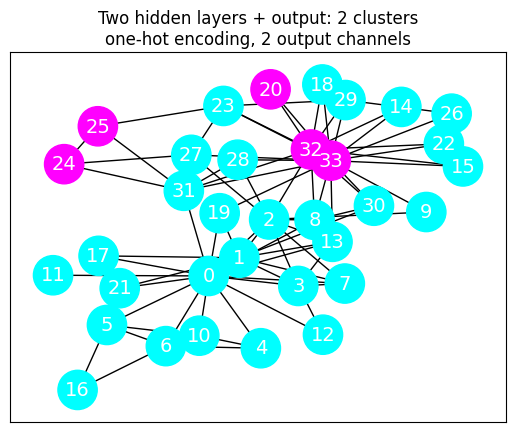

In [314]:
kmeans = get_clusters(Z, num_clusters = 2)

G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 2 clusters\none-hot encoding, 2 output channels")

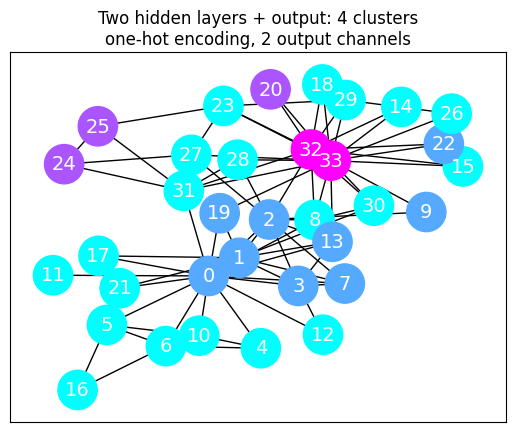

In [315]:
kmeans = get_clusters(Z, num_clusters = 4)

#print(kmeans.labels_)
G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Two hidden layers + output: 4 clusters\none-hot encoding, 2 output channels")

What happens with the bare bones autoencoder?

In [316]:
class Encoder(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Encoder, self).__init__()
        self.output = GCNConv(in_channels, out_channels)
    def forward(self, x, edge_index):
        z = self.output(x, edge_index)
        return z
out_channels = 3
num_features = torch.Tensor.size(data.x)[1]
print(num_features)
if 'model' in globals(): del model
model = GAE(Encoder(num_features, out_channels))
print(model)

34
GAE(
  (encoder): Encoder(
    (output): GCNConv(34, 3)
  )
  (decoder): InnerProductDecoder()
)


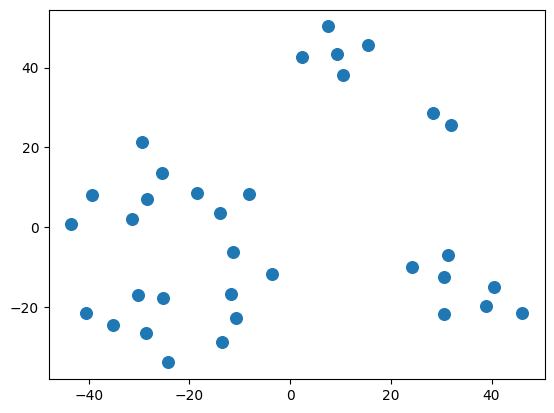

In [317]:
epochs = 1000

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(1, epochs):
    z = train(data, model, neg_edge_index, optimizer)
model.eval()
with torch.no_grad():
    Z = model.encode(data.x, data.edge_index).detach().numpy()

visualize(Z)

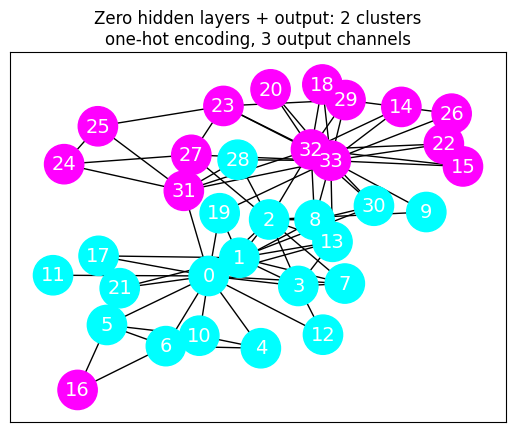

In [318]:
kmeans = get_clusters(Z, num_clusters = 2)

G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 2 clusters\none-hot encoding, 3 output channels")

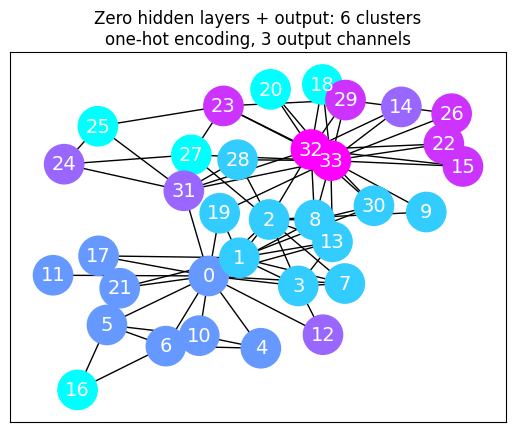

In [319]:
kmeans = get_clusters(Z, num_clusters = 6)

G = nx.karate_club_graph()
nx.draw_networkx(G, 
                 #pos=nx.spring_layout(G,seed=0), 
                 pos = nx.nx_pydot.graphviz_layout(G,prog="neato"),
                 node_color=kmeans.labels_,
                 node_size=800,
                 cmap='cool',
                 font_size=14,
                 font_color='white')
_ = plt.title("Zero hidden layers + output: 6 clusters\none-hot encoding, 3 output channels")

---
---
